In [ ]:
# reload to load packages
%load_ext autoreload
%autoreload 2

In [1]:
# read the spatial units
import geopandas as gpd
import xarray as xr
import numpy as np
import rioxarray as rio
import pandas as pd
import glob
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from chord import Chord
import xvec
# import pyarrow

# import xesmf as xe
import duckdb
import warnings
warnings.filterwarnings('ignore')


### CDR Data using DB


In [2]:
con = duckdb.connect("mobility_data/mobility_data_processed.duckdb")

In [3]:
# # read parquet files inside the con

# con.execute("""
#             CREATE OR REPLACE TABLE weighted AS SELECT * FROM 'mobility_data/mobility_data_processed.parquet'
#             WHERE weight_type = 'weighted' AND days_span = '30days' AND subset_type = 'A'

#             """).df().head(5)
# con.execute("""
#             CREATE OR REPLACE TABLE unweighted AS SELECT * FROM 'mobility_data/mobility_data_processed.parquet'
#             WHERE weight_type = 'unweighted' AND days_span = '30days' AND subset_type = 'A'
#             """).df().head(5)

### DB - Data manipulation

It is very similar to SQL and very fast on the parquet files. Since the data is arranged in columns and it is quite nice to column query data and CREATE the desired tables.

The queries are exactly same as you would do in any SQL management systems.

In [4]:
# see what is in the database
con.execute("SHOW TABLES").fetchall()
# remove the table if it exists
# con.execute("DROP TABLE IF EXISTS mobility_data_processed").fetchall()

[('unweighted',), ('weighted',)]

In [5]:
# print(con.execute("SELECT * FROM unweighted LIMIT 5").df())
# print(con.execute("SELECT * FROM weighted LIMIT 5").df())

In [8]:
# select rows for one spatial unit and one weight type
con.execute("SELECT * FROM unweighted WHERE origin = 'city-001' LIMIT 5").df()

,origin,destination,HalfMonthIndex,N_depart,N_return,rate_depart,rate_return,N_users_observed_depart,N_users_observed_return,N_migrants,...,subset_type,days_span,norm_spatial_id_origin,norm_spatial_id_destination,origin_name,destination_name,date,origin_type,destination_type,flow_type
0,city-001,SEN.14.3.1_1-rural,20130201,0.0,0.0,0.0,0.0,4769.0,4760.0,0.0,...,A,30days,city-001,sen.14.3.1,Bambey,Niaguis-rural,2013-02-01,urban,rural,urban → rural
1,city-001,SEN.14.3.1_1-rural,20130216,0.0,0.0,0.0,0.0,4769.0,4769.0,0.0,...,A,30days,city-001,sen.14.3.1,Bambey,Niaguis-rural,2013-02-16,urban,rural,urban → rural
2,city-001,SEN.14.3.1_1-rural,20130301,0.0,0.0,0.0,0.0,4769.0,4770.0,0.0,...,A,30days,city-001,sen.14.3.1,Bambey,Niaguis-rural,2013-03-01,urban,rural,urban → rural
3,city-001,SEN.14.3.1_1-rural,20130316,0.0,0.0,0.0,0.0,4770.0,4769.0,0.0,...,A,30days,city-001,sen.14.3.1,Bambey,Niaguis-rural,2013-03-16,urban,rural,urban → rural
4,city-001,SEN.14.3.1_1-rural,20130401,0.0,0.0,0.0,0.0,4768.0,4770.0,0.0,...,A,30days,city-001,sen.14.3.1,Bambey,Niaguis-rural,2013-04-01,urban,rural,urban → rural


***Interpretation***: 

From the table above, it can be infered that the weighted set already has the pop denominator.

$$W_{l,t} = pop_{l,t} /{nusers}_{l,t}$$



### Recover target pop from weighted rates

But this technique only works for data > 0 columns.

In [28]:
# show tables
con.execute("SHOW TABLES").fetchall()

[('unweighted',), ('weighted',)]

In [33]:
pop_from_weighted = con.sql(
    f"""
WITH row_pop AS (
    SELECT
        norm_spatial_id_origin, origin_name, HalfMonthIndex, date, weight_type, days_span, subset_type, N_depart,
        N_return, rate_depart, rate_return,

        CASE
            WHEN N_depart >0 AND rate_depart > 0 THEN N_depart/rate_depart
            ELSE NULL
        END AS pop_depart,
        CASE
            WHEN N_return >0 AND rate_return > 0 THEN N_return/rate_return
            ELSE NULL
        END AS pop_return
    FROM weighted
    )
SELECT 
    norm_spatial_id_origin, origin_name, HalfMonthIndex, date, weight_type, days_span, subset_type,
        MAX(pop_depart) AS pop_depart, 
        MAX(pop_return) AS pop_return,

        COUNT(pop_depart) AS positive_pop_depart,
        COUNT(pop_return) AS positive_pop_return,

        MIN(pop_depart) AS min_pop_depart,
        MIN(pop_return) AS min_pop_return,

FROM row_pop
GROUP BY norm_spatial_id_origin, origin_name, HalfMonthIndex, date, weight_type, days_span, subset_type
ORDER BY norm_spatial_id_origin, date, HalfMonthIndex
    """
).df()

pop_from_weighted

,norm_spatial_id_origin,origin_name,HalfMonthIndex,date,weight_type,days_span,subset_type,pop_depart,pop_return,positive_pop_depart,positive_pop_return,min_pop_depart,min_pop_return
0,city-001,Bambey,20130201,2013-02-01,weighted,30days,A,54515.947210,54515.947210,19,31,54515.947210,54515.947210
1,city-001,Bambey,20130216,2013-02-16,weighted,30days,A,54593.779462,54593.779462,13,18,54593.779462,54593.779462
2,city-001,Bambey,20130301,2013-03-01,weighted,30days,A,54671.722835,54671.722835,11,26,54671.722835,54671.722835
3,city-001,Bambey,20130316,2013-03-16,weighted,30days,A,54749.777488,54749.777488,13,34,54749.777488,54749.777488
4,city-001,Bambey,20130401,2013-04-01,weighted,30days,A,54827.943578,54827.943578,33,12,54827.943578,54827.943578
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9659,sen.9.3.1,Velingara-rural,20150916,2015-09-16,weighted,30days,A,30906.477841,30906.477841,23,22,30906.477841,30906.477841
9660,sen.9.3.1,Velingara-rural,20151001,2015-10-01,weighted,30days,A,30942.774277,30942.774277,17,39,30942.774277,30942.774277
9661,sen.9.3.1,Velingara-rural,20151016,2015-10-16,weighted,30days,A,30979.113341,30979.113341,21,25,30979.113341,30979.113341
9662,sen.9.3.1,Velingara-rural,20151101,2015-11-01,weighted,30days,A,31015.495080,31015.495080,19,18,31015.495080,31015.495080


In [9]:
con.execute("SELECT * FROM weighted WHERE origin = 'city-001' LIMIT 5").df()

,origin,destination,HalfMonthIndex,N_depart,N_return,rate_depart,rate_return,N_users_observed_depart,N_users_observed_return,N_migrants,...,subset_type,days_span,norm_spatial_id_origin,norm_spatial_id_destination,origin_name,destination_name,date,origin_type,destination_type,flow_type
0,city-001,SEN.14.3.1_1-rural,20130201,0.0,0.0,0.0,0.0,54515.947210,54515.947210,0.0,...,A,30days,city-001,sen.14.3.1,Bambey,Niaguis-rural,2013-02-01,urban,rural,urban → rural
1,city-001,SEN.14.3.1_1-rural,20130216,0.0,0.0,0.0,0.0,54593.779462,54593.779462,0.0,...,A,30days,city-001,sen.14.3.1,Bambey,Niaguis-rural,2013-02-16,urban,rural,urban → rural
2,city-001,SEN.14.3.1_1-rural,20130301,0.0,0.0,0.0,0.0,54671.722835,54671.722835,0.0,...,A,30days,city-001,sen.14.3.1,Bambey,Niaguis-rural,2013-03-01,urban,rural,urban → rural
3,city-001,SEN.14.3.1_1-rural,20130316,0.0,0.0,0.0,0.0,54749.777488,54749.777488,0.0,...,A,30days,city-001,sen.14.3.1,Bambey,Niaguis-rural,2013-03-16,urban,rural,urban → rural
4,city-001,SEN.14.3.1_1-rural,20130401,0.0,0.0,0.0,0.0,54827.943578,54827.943578,0.0,...,A,30days,city-001,sen.14.3.1,Bambey,Niaguis-rural,2013-04-01,urban,rural,urban → rural


### Create Wider Tables

Tables that can support origin x time based analysis and reporting. 

For every subset_type and days_span, create these outputs:

- mobility_long_{subset_type}_{days_span}.parquet
- mobility_origin_time_{subset_type}_{days_span}.parquet
- mobility_wide_{subset_type}_{days_span}.parquet

**origin_time table**

<table>
  <tr>
    <td>origin unit</td>
    <td>date</td>
    <td>total_depart</td>
    <td>total_return</td>
    <td>positive_pop_depart</td>
    <td>pop_observed_depart</td>
    <td>pop_observed_return</td>
    <td>positive_pop_return</td>
    <td> rural-urban shares</td>
  </tr>
</table>



In [23]:
def safe_col(value):
    value = str(value).lower().strip()
    value = value.replace("→", "to")
    value = re.sub(r"[^a-z0-9]+", "_", value)
    value = re.sub(r"_+", "_", value)
    return value.strip("_")

In [ ]:
## Main function to create long, wide, and country tables

def build_long_wide_tables(df, output_dir, table_label):
    df = df.copy()

    # Make sure date is datetime
    df["date"] = pd.to_datetime(df["date"])

    # Core origin-time columns
    origin_time_cols = [
        "norm_spatial_id_origin",
        "origin_name",
        "origin_type",
        "HalfMonthIndex",
        "date",
        "subset_type",
        "days_span"
    ]

    # OD-level columns
    od_cols = origin_time_cols + [
        "norm_spatial_id_destination",
        "destination_name",
        "destination_type",
        "flow_type"
    ]

    # First aggregate to one row per OD-time
    # This protects you if there are accidental duplicate rows
    long_od = (
        df
        .groupby(od_cols, observed=True, dropna=False)
        .agg(
            N_depart=("N_depart", "sum"),
            N_return=("N_return", "sum"),
            N_migrants=("N_migrants", "sum"),

            # Do not sum these. They are repeated denominators/users.
            pop_observed_depart=("N_users_observed_depart", "max"),
            pop_observed_return=("N_users_observed_return", "max"),

            rate_depart=("rate_depart", "max"),
            rate_return=("rate_return", "max")
        )
        .reset_index()
    )

    # Destination label for wide columns
    long_od["dest_label"] = (
        long_od["destination_name"].fillna("unknown").map(safe_col)
        + "__"
        + long_od["norm_spatial_id_destination"].fillna("unknown").map(safe_col)
    )

    # Origin-time summary
    summary = (
        long_od
        .groupby(origin_time_cols, observed=True, dropna=False)
        .agg(
            total_depart=("N_depart", "sum"),
            total_return=("N_return", "sum"),
            total_migrants=("N_migrants", "sum"),

            # Your requested columns:
            # number of destinations with positive departure / return
            positive_pop_depart=("N_depart", lambda x: int((x > 0).sum())),
            positive_pop_return=("N_return", lambda x: int((x > 0).sum())),

            # clearer aliases
            n_positive_dest_depart=("N_depart", lambda x: int((x > 0).sum())),
            n_positive_dest_return=("N_return", lambda x: int((x > 0).sum())),

            n_destinations=("norm_spatial_id_destination", "nunique"),

            # Max denominator/users at origin-time level
            pop_observed_depart=("pop_observed_depart", "max"),
            pop_observed_return=("pop_observed_return", "max")
        )
        .reset_index()
    )

    # Wide departure matrix: one column per destination
    depart_wide = (
        long_od
        .pivot_table(
            index=origin_time_cols,
            columns="dest_label",
            values="N_depart",
            aggfunc="sum",
            fill_value=0
        )
    )

    depart_wide.columns = [
        f"depart_to__{c}" for c in depart_wide.columns
    ]

    depart_wide = depart_wide.reset_index()

    # Wide return matrix: one column per destination
    return_wide = (
        long_od
        .pivot_table(
            index=origin_time_cols,
            columns="dest_label",
            values="N_return",
            aggfunc="sum",
            fill_value=0
        )
    )

    return_wide.columns = [
        f"return_from__{c}" for c in return_wide.columns
    ]

    return_wide = return_wide.reset_index()

    # Flow type totals
    flow_type_summary = (
        long_od
        .groupby(origin_time_cols + ["flow_type"], observed=True, dropna=False)
        .agg(
            depart_flow=("N_depart", "sum"),
            return_flow=("N_return", "sum")
        )
        .reset_index()
    )

    flow_type_summary["flow_type_clean"] = flow_type_summary["flow_type"].map(safe_col)

    depart_flow_wide = (
        flow_type_summary
        .pivot_table(
            index=origin_time_cols,
            columns="flow_type_clean",
            values="depart_flow",
            aggfunc="sum",
            fill_value=0
        )
    )

    depart_flow_wide.columns = [
        f"depart_flow__{c}" for c in depart_flow_wide.columns
    ]

    depart_flow_wide = depart_flow_wide.reset_index()

    return_flow_wide = (
        flow_type_summary
        .pivot_table(
            index=origin_time_cols,
            columns="flow_type_clean",
            values="return_flow",
            aggfunc="sum",
            fill_value=0
        )
    )

    return_flow_wide.columns = [
        f"return_flow__{c}" for c in return_flow_wide.columns
    ]

    return_flow_wide = return_flow_wide.reset_index()

    # Merge everything into one wide origin-time table
    wide_origin_time = (
        summary
        .merge(depart_wide, on=origin_time_cols, how="left")
        .merge(return_wide, on=origin_time_cols, how="left")
        .merge(depart_flow_wide, on=origin_time_cols, how="left")
        .merge(return_flow_wide, on=origin_time_cols, how="left")
    )

    wide_origin_time = wide_origin_time.fillna(0)

    # Add rural-urban / urban-rural shares from flow_type
    depart_flow_cols = [
        c for c in wide_origin_time.columns
        if c.startswith("depart_flow__")
    ]

    return_flow_cols = [
        c for c in wide_origin_time.columns
        if c.startswith("return_flow__")
    ]

    for col in depart_flow_cols:
        share_col = col.replace("depart_flow__", "depart_share__")
        wide_origin_time[share_col] = np.where(
            wide_origin_time["total_depart"] > 0,
            wide_origin_time[col] / wide_origin_time["total_depart"],
            0
        )

    for col in return_flow_cols:
        share_col = col.replace("return_flow__", "return_share__")
        wide_origin_time[share_col] = np.where(
            wide_origin_time["total_return"] > 0,
            wide_origin_time[col] / wide_origin_time["total_return"],
            0
        )

    # Country-level time series 

    # make columns for flow_type totals and shares
    
    country_ts = (
        long_od
        .groupby(
            ["HalfMonthIndex", "date", "subset_type", "days_span"],
            observed=True,
            dropna=False
        )
        .agg(
            country_total_depart=("N_depart", "sum"),
            country_total_return=("N_return", "sum"),
            country_total_migrants=("N_migrants", "sum"),
            country_positive_od_depart=("N_depart", lambda x: int((x > 0).sum())),
            country_positive_od_return=("N_return", lambda x: int((x > 0).sum())),
            country_n_origins=("norm_spatial_id_origin", "nunique"),
            country_n_destinations=("norm_spatial_id_destination", "nunique")
        )
        .reset_index()
        .sort_values("date")
    )

    # Save tables
    long_path = output_dir / f"long_od_time_{table_label}.parquet"
    wide_path = output_dir / f"wide_origin_time_{table_label}.parquet"
    country_path = output_dir / f"country_time_{table_label}.parquet"

    long_od.to_parquet(long_path, index=False)
    wide_origin_time.to_parquet(wide_path, index=False)
    country_ts.to_parquet(country_path, index=False)

    print("Saved:")
    print(long_path)
    print(wide_path)
    print(country_path)

    return long_od, wide_origin_time, country_ts

In [72]:

output_dir = Path("processed_mobility_tables")
output_dir.mkdir(parents=True, exist_ok=True)
df = pd.read_parquet("/home/kzakir/dvcube/CDRxClimate/cdrxclimate/cdr_test/mobility_data/mobility_data_processed.parquet")
# df filter for subset_type = 'A', days_span = '60days', weight_type = 'weighted'
df = df[(df["subset_type"] == "A") & (df["days_span"] == "20days") & (df["weight_type"] == "weighted")]
df

,origin,destination,HalfMonthIndex,N_depart,N_return,rate_depart,rate_return,N_users_observed_depart,N_users_observed_return,N_migrants,...,subset_type,days_span,norm_spatial_id_origin,norm_spatial_id_destination,origin_name,destination_name,date,origin_type,destination_type,flow_type
11234400,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130116,0.000000,0.0,0.000000,0.0,14922.505740,14922.505740,0.000000,...,A,20days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-01-16,rural,rural,rural → rural
11234401,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130201,0.000000,0.0,0.000000,0.0,14935.591584,14935.591584,0.000000,...,A,20days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-02-01,rural,rural,rural → rural
11234402,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130216,0.000000,0.0,0.000000,0.0,14948.688902,14948.688902,0.000000,...,A,20days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-02-16,rural,rural,rural → rural
11234403,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130301,0.000000,0.0,0.000000,0.0,14961.797707,14961.797707,0.000000,...,A,20days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-03-01,rural,rural,rural → rural
11234404,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130316,0.000000,0.0,0.000000,0.0,14974.918006,14974.918006,0.000000,...,A,20days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-03-16,rural,rural,rural → rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12774595,city-008,city-017,20151001,0.000000,0.0,0.000000,0.0,13442.315421,13442.315421,0.000000,...,A,20days,city-008,city-017,Diaobé,Kébémer,2015-10-01,urban,urban,urban → urban
12774596,city-008,city-017,20151016,0.000000,0.0,0.000000,0.0,13468.561212,13468.561212,0.000000,...,A,20days,city-008,city-017,Diaobé,Kébémer,2015-10-16,urban,urban,urban → urban
12774597,city-008,city-017,20151101,0.000000,0.0,0.000000,0.0,13494.858246,13494.858246,0.000000,...,A,20days,city-008,city-017,Diaobé,Kébémer,2015-11-01,urban,urban,urban → urban
12774598,city-008,city-017,20151116,0.000000,0.0,0.000000,0.0,13521.206625,13521.206625,0.000000,...,A,20days,city-008,city-017,Diaobé,Kébémer,2015-11-16,urban,urban,urban → urban


In [73]:
long_od, wide_origin_time, country_ts = build_long_wide_tables(
    df,
    output_dir=output_dir,
    table_label="weighted_A_20days"
)

Saved:
processed_mobility_tables/long_od_time_weighted_A_20days.parquet
processed_mobility_tables/wide_origin_time_weighted_A_20days.parquet
processed_mobility_tables/country_time_weighted_A_20days.parquet


In [74]:
long_od

,norm_spatial_id_origin,origin_name,origin_type,HalfMonthIndex,date,subset_type,days_span,norm_spatial_id_destination,destination_name,destination_type,flow_type,N_depart,N_return,N_migrants,pop_observed_depart,pop_observed_return,rate_depart,rate_return,dest_label
0,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-002,Bignona,urban,urban → urban,0.000000,11.494558,0.000000,54438.225920,54438.225920,0.000000,0.000211,bignona__city_002
1,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-004,Dagana,urban,urban → urban,0.000000,0.000000,11.472756,54438.225920,54438.225920,0.000000,0.000000,dagana__city_004
2,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-005,Dahra Djoloff,urban,urban → urban,0.000000,0.000000,0.000000,54438.225920,54438.225920,0.000000,0.000000,dahra_djoloff__city_005
3,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-006,Dakar,urban,urban → urban,285.495206,218.396599,1135.802817,54438.225920,54438.225920,0.005244,0.004012,dakar__city_006
4,city-001,Bambey,urban,20130116,2013-01-16,A,20days,city-007,Darou Mousty,urban,urban → urban,0.000000,0.000000,0.000000,54438.225920,54438.225920,0.000000,0.000000,darou_mousty__city_007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1540195,sen.9.3.1,Velingara-rural,rural,20151201,2015-12-01,A,20days,sen.8.3.4,Sakal-rural,rural,rural → rural,0.000000,0.000000,0.000000,31088.386789,31088.386789,0.000000,0.000000,sakal_rural__sen_8_3_4
1540196,sen.9.3.1,Velingara-rural,rural,20151201,2015-12-01,A,20days,sen.9.1.1,Orkadiere-rural,rural,rural → rural,16.016686,0.000000,79.713812,31088.386789,31088.386789,0.000515,0.000000,orkadiere_rural__sen_9_1_1
1540197,sen.9.3.1,Velingara-rural,rural,20151201,2015-12-01,A,20days,sen.9.1.2,Ouro Sidy-rural,rural,rural → rural,0.000000,31.852855,63.771050,31088.386789,31088.386789,0.000000,0.001025,ouro_sidy_rural__sen_9_1_2
1540198,sen.9.3.1,Velingara-rural,rural,20151201,2015-12-01,A,20days,sen.9.2.1,Agnam Civol-rural,rural,rural → rural,32.033371,15.926428,191.313149,31088.386789,31088.386789,0.001030,0.000512,agnam_civol_rural__sen_9_2_1


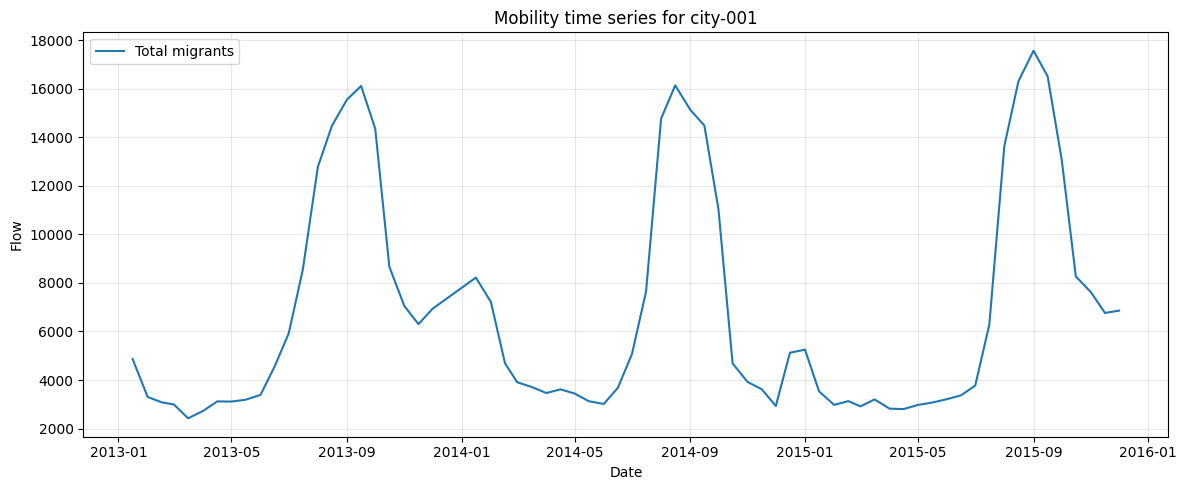

In [75]:
unit_id = "city-001"

unit_ts = (
    wide_origin_time
    .query("norm_spatial_id_origin == @unit_id")
    .sort_values("date")
)

plt.figure(figsize=(12, 5))

# plt.plot(unit_ts["date"], unit_ts["total_depart"], label="Total departures")
plt.plot(unit_ts["date"], unit_ts["total_migrants"], label="Total migrants")

plt.xlabel("Date")
plt.ylabel("Flow")
plt.title(f"Mobility time series for {unit_id}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

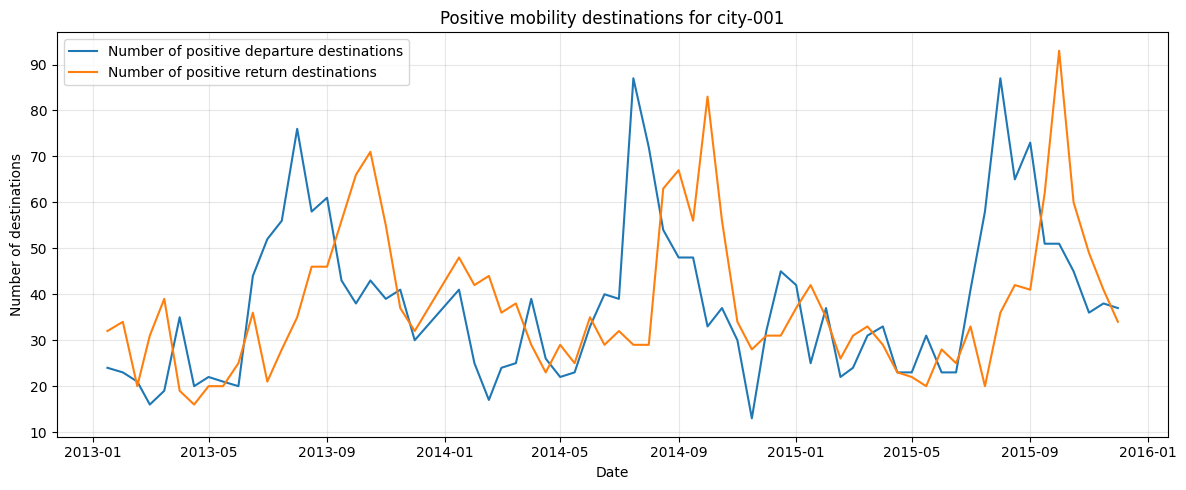

In [76]:
## This shows how many destinations people moved to or returned from at each timestep.

plt.figure(figsize=(12, 5))

plt.plot(
    unit_ts["date"],
    unit_ts["positive_pop_depart"],
    label="Number of positive departure destinations"
)

plt.plot(
    unit_ts["date"],
    unit_ts["positive_pop_return"],
    label="Number of positive return destinations"
)

plt.xlabel("Date")
plt.ylabel("Number of destinations")
plt.title(f"Positive mobility destinations for {unit_id}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [77]:
[c for c in wide_origin_time.columns if "dakar" in c and c.startswith("depart_to__")][:10]

['depart_to__dakar__city_006', 'depart_to__dakar_rural__sen_1_1_1']

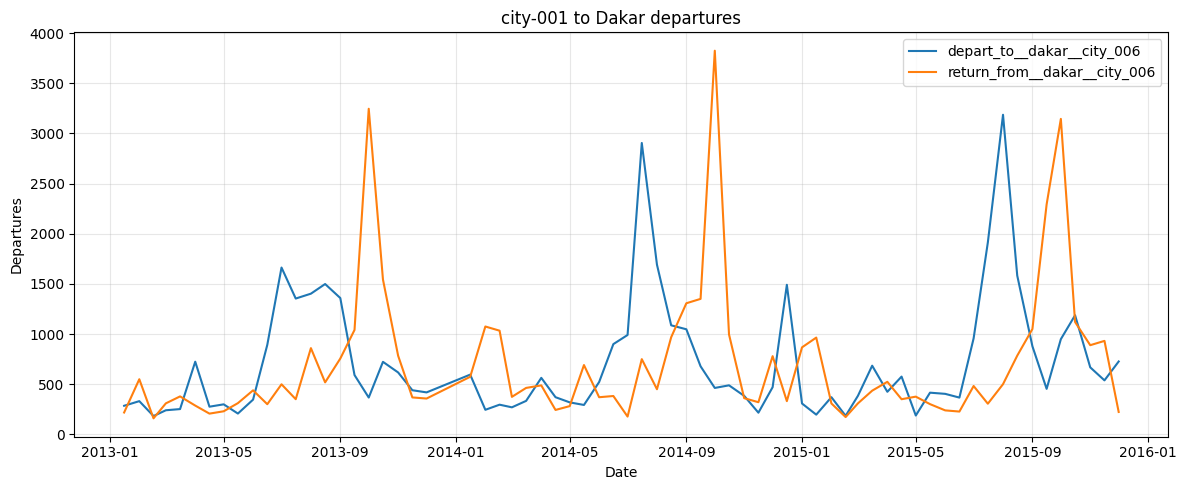

In [78]:
dest_col = "depart_to__dakar__city_006"
dest_col2 = "depart_to__dakar_rural__sen_1_1_1"
return_col = "return_from__dakar__city_006"
plt.figure(figsize=(12, 5))

plt.plot(unit_ts["date"], unit_ts[dest_col], label=dest_col)
# plt.plot(unit_ts["date"], unit_ts[dest_col2], label=dest_col2)
plt.plot(unit_ts["date"], unit_ts[return_col], label=return_col)

plt.xlabel("Date")
plt.ylabel("Departures")
plt.title(f"{unit_id} to Dakar departures")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

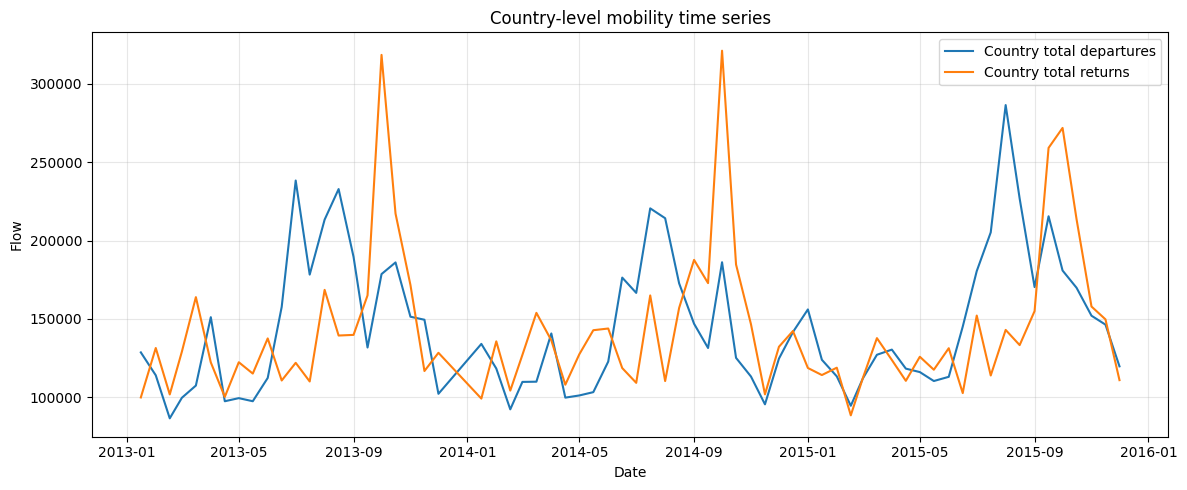

In [79]:
country_ts = country_ts.sort_values("date")

plt.figure(figsize=(12, 5))

plt.plot(
    country_ts["date"],
    country_ts["country_total_depart"],
    label="Country total departures"
)

plt.plot(
    country_ts["date"],
    country_ts["country_total_return"],
    label="Country total returns"
)

plt.xlabel("Date")
plt.ylabel("Flow")
plt.title("Country-level mobility time series")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [80]:
unit_ts = unit_ts.sort_values("date")

share_cols = [
    c for c in unit_ts.columns
    if c.startswith("depart_share__")
]

share_cols

['depart_share__rural_to_rural',
 'depart_share__rural_to_urban',
 'depart_share__urban_to_rural',
 'depart_share__urban_to_urban']

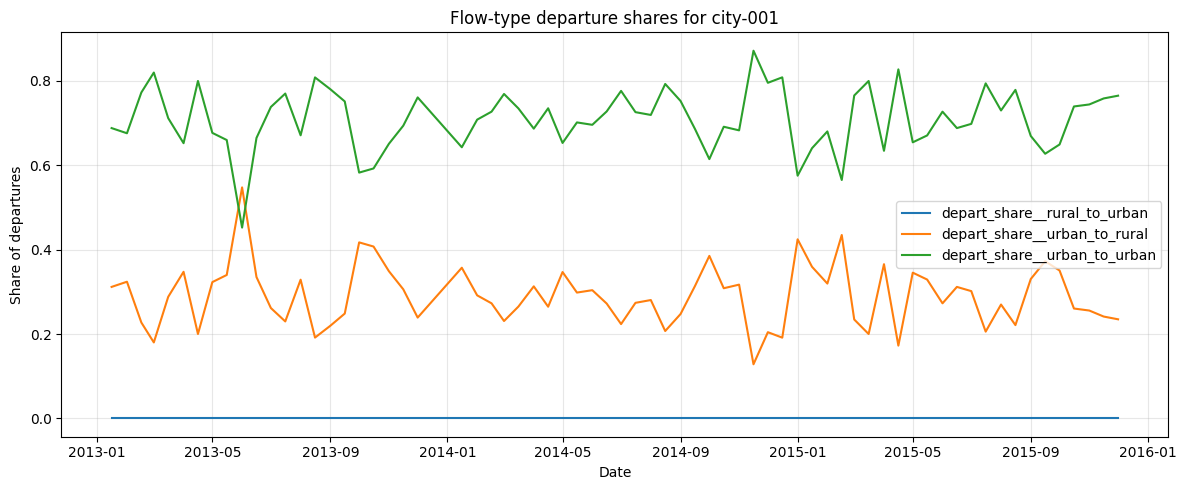

In [81]:
selected_share_cols = [
    c for c in share_cols
    if "rural_to_urban" in c or "urban_to_rural" in c or "urban_to_urban" in c
]

plt.figure(figsize=(12, 5))

for col in selected_share_cols:
    plt.plot(unit_ts["date"], unit_ts[col], label=col)

plt.xlabel("Date")
plt.ylabel("Share of departures")
plt.title(f"Flow-type departure shares for {unit_id}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# # make 4 parquet files for each weight type and subset type combination
# weight_types = mob_data['weight_type'].unique()
# subset_types = mob_data['subset_type'].unique()
# for weight in weight_types:
#     for subset in subset_types:
#         subset_data = mob_data[(mob_data['weight_type'] == weight) & (mob_data['subset_type'] == subset)]
#         output_path = f'mobility_data_{weight}_{subset}.parquet'
#         subset_data.to_parquet(output_path)
#         print(f"Saved {output_path} with {len(subset_data)} records.") 

        

## Flow Maps with Parquet Files

#### Helpers For Plots


In [4]:
# Build the four subsets
subsets = {
    'unweighted_a': mob_data[(mob_data['weight_type'] == 'unweighted') & (mob_data['subset_type'] == 'A')],
    'unweighted_b': mob_data[(mob_data['weight_type'] == 'unweighted') & (mob_data['subset_type'] == 'B')],
    'weighted_a':   mob_data[(mob_data['weight_type'] == 'weighted')   & (mob_data['subset_type'] == 'A')],
    'weighted_b':   mob_data[(mob_data['weight_type'] == 'weighted')   & (mob_data['subset_type'] == 'B')],
}

# Dakar filter 
def drop_dakar(df):
    return df[(df['origin_name'] != 'Dakar') & (df['destination_name'] != 'Dakar')]

dakar_variants = {
    'with_dakar':    subsets,
    'without_dakar': {k: drop_dakar(v) for k, v in subsets.items()},
}

# Season for senegal that is dry and wet (dry: Nov-Apr, wet: May-Oct)
season_colors = {
    1: "#f09948",  # Dry season (Nov-Apr)
    2: "#2b8de9",  # Wet season (May-Oct)
}
season_labels = {
    1: "Dry season (Nov-Apr)",
    2: "Wet season (May-Oct)",
}

def add_season(df):
    df = df.copy()
    df['month'] = df['date'].dt.month
    df['season'] = np.where(df['month'].isin([11, 12, 1, 2, 3, 4]), 1, 2)  #
    return df

def axvspan_seasons(ax, df):
    df = df.sort_values('date').drop_duplicates('date')
    current_season, block_start = None, None
    for _, row in df.iterrows():
        if row['season'] != current_season:
            if current_season is not None:
                ax.axvspan(block_start, row['date'],
                           color=season_colors[current_season], alpha=0.12, linewidth=0, zorder=0)
            current_season, block_start = row['season'], row['date']
    if current_season is not None:
        ax.axvspan(block_start, df['date'].iloc[-1],
                   color=season_colors[current_season], alpha=0.12, linewidth=0, zorder=0)

col_keys   = ['unweighted_a', 'unweighted_b', 'weighted_a', 'weighted_b']
col_labels = ['Unweighted A', 'Unweighted B', 'Weighted A', 'Weighted B']

# Infer days_span values from data
days_spans = sorted(mob_data['days_span'].unique())

#### For each metric plot helpers

from matplotlib.lines import Line2D

# color by days_span
cmap = plt.get_cmap('tab10', len(days_spans))
days_colors = {
    ds: cmap(i)
    for i, ds in enumerate(days_spans)
}

# Metrics to plot separately
metrics = {
    'N_depart': {
        'title': 'Destination flow',
        'ylabel': 'Flow count',
        'filename': 'destination_flow'
    },
    'N_return': {
        'title': 'Returns',
        'ylabel': 'Return count',
        'filename': 'returns'
    },
    'N_migrants': {
        'title': 'Migrant stock',
        'ylabel': 'Migrant stock count',
        'filename': 'migrants'
    }
}

def aggregate_metric(df, days_span, metric):
    df = add_season(df)

    df_ds = df[df['days_span'] == days_span]

    if df_ds.empty:
        return pd.DataFrame()

    df_ts = (
        df_ds
        .groupby('date', as_index=False)
        .agg(
            value=(metric, 'sum'),
            season=('season', 'first')
        )
        .sort_values('date')
    )

    return df_ts



#### Mobility Flows With/Without Dakar

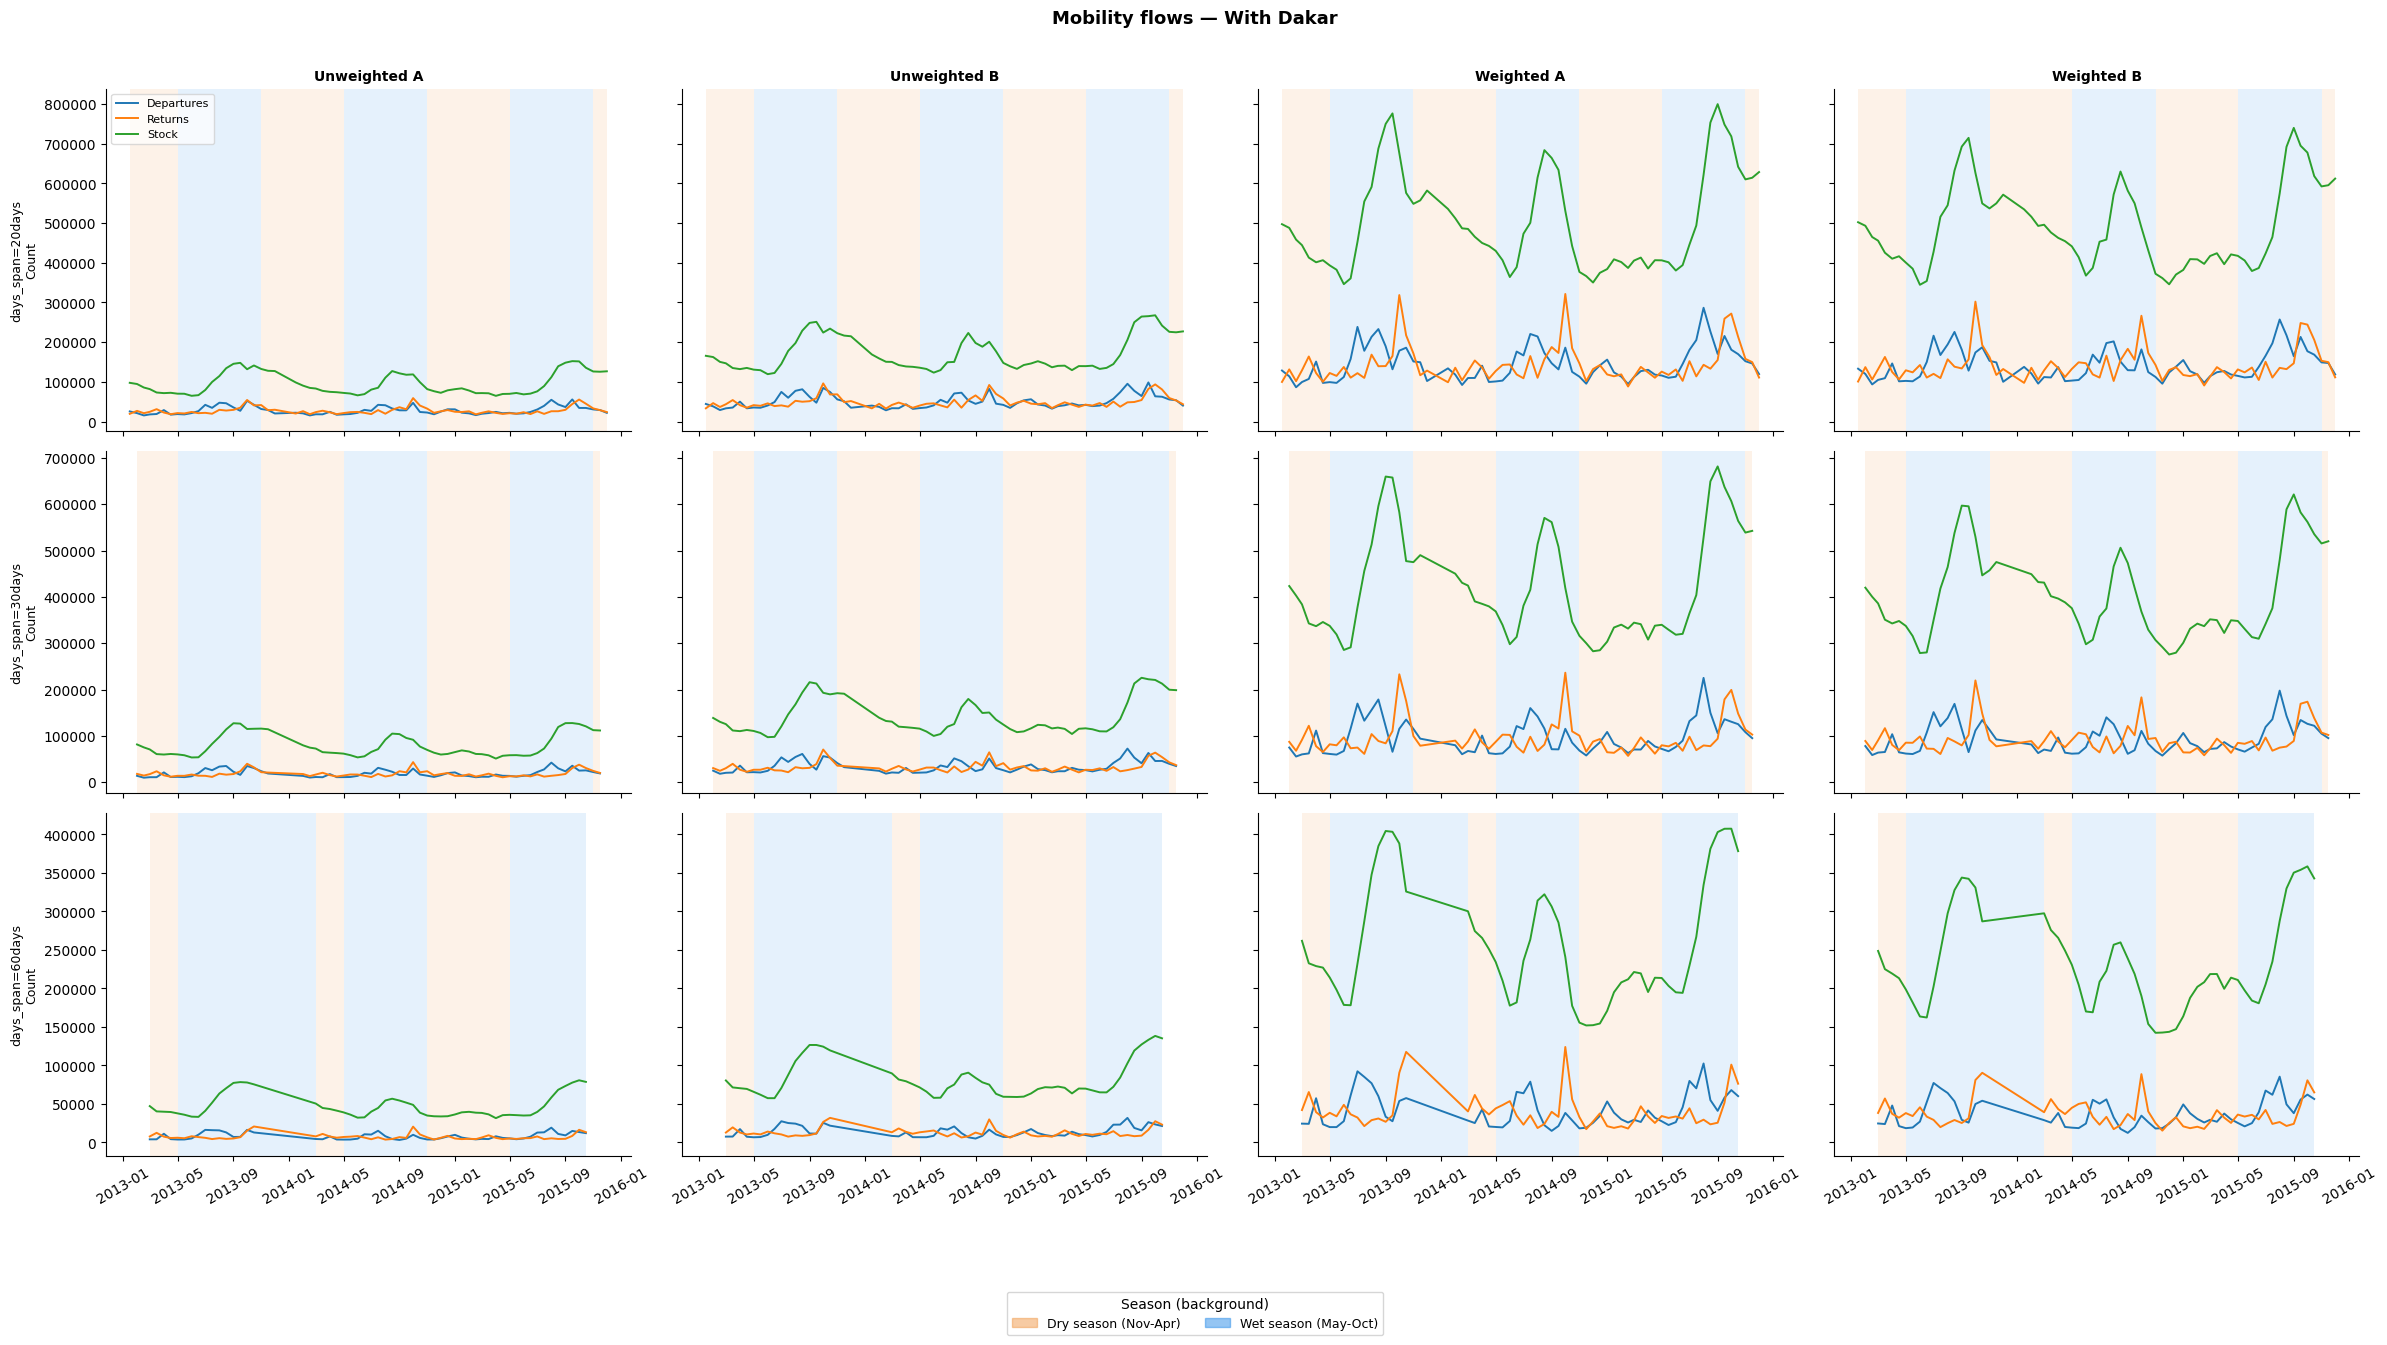

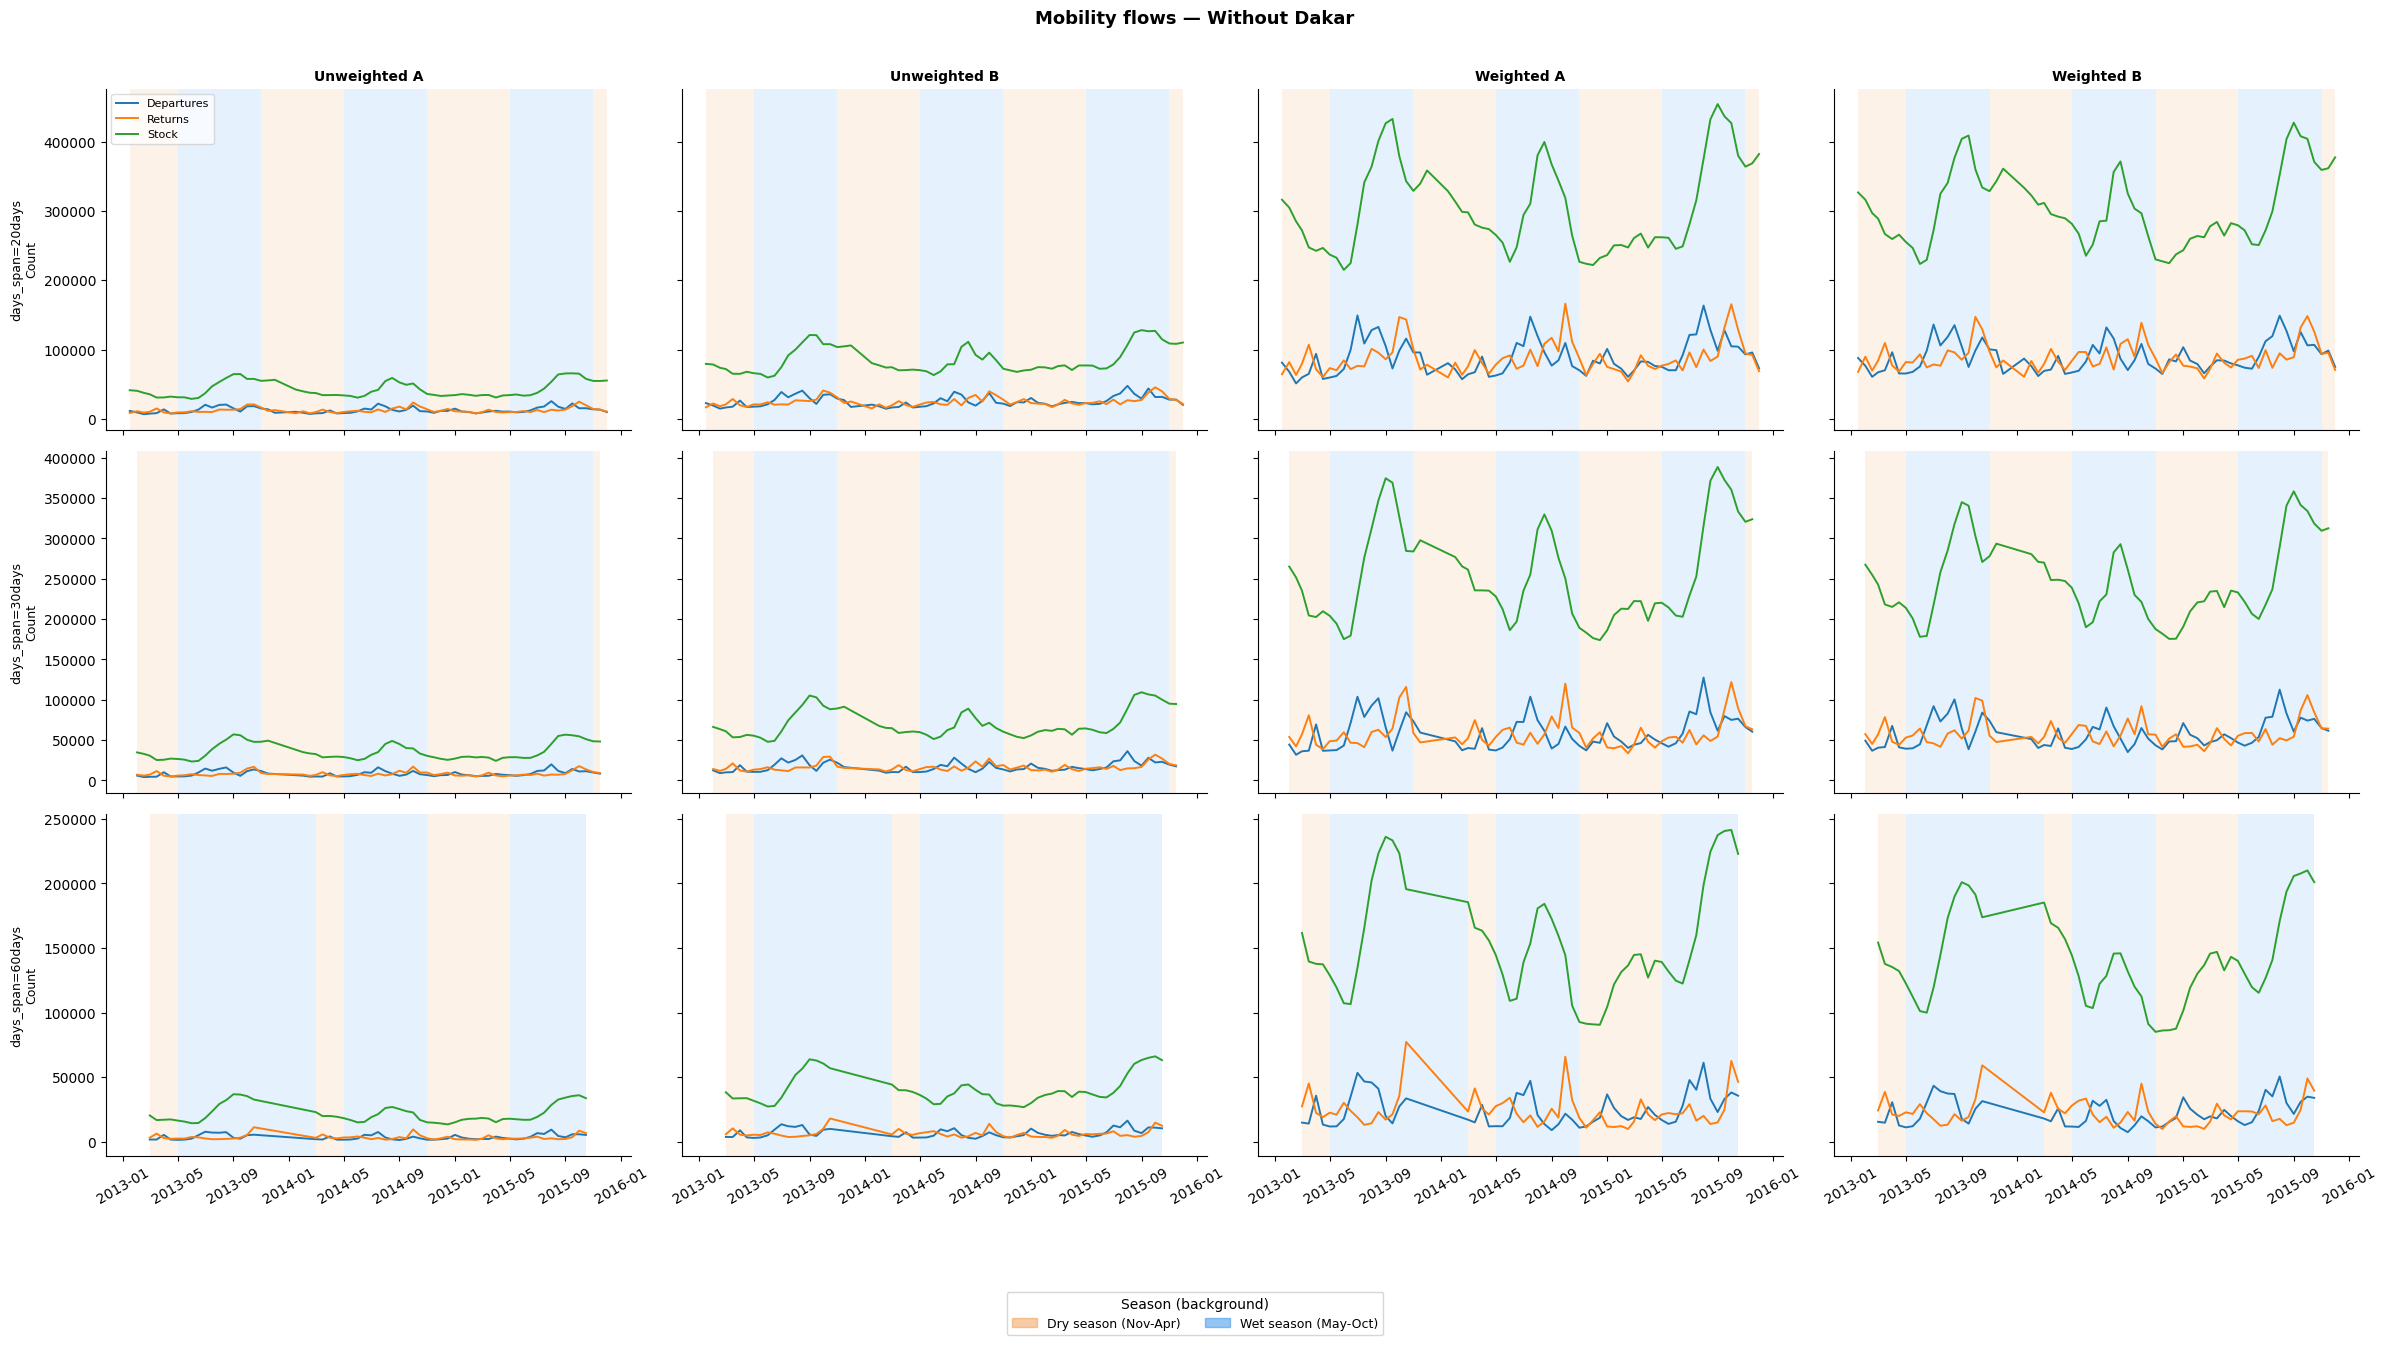

In [ ]:
# One figure per dakar variant 
for dakar_key, subset_dict in dakar_variants.items():

    nrows = len(days_spans)
    ncols = len(col_keys)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 4 * nrows),
                             sharex=True, sharey='row')

    for r, ds in enumerate(days_spans):
        for c, col_key in enumerate(col_keys):
            ax = axes[r, c]

            df = add_season(subset_dict[col_key])

            # Filter to this days_span
            df_ds = df[df['days_span'] == ds]

            # Aggregate nationally across OD pairs
            df_ts = (
                df_ds.groupby('date', as_index=False)
                .agg(
                    N_depart   =('N_depart',   'sum'),
                    N_return   =('N_return',   'sum'),
                    N_migrants =('N_migrants', 'sum'),
                    season     =('season',     'first'),
                )
                .sort_values('date')
            )

            if df_ts.empty:
                ax.set_visible(False)
                continue

            axvspan_seasons(ax, df_ts)

            ax.plot(df_ts['date'], df_ts['N_depart'],   label='Departures', color='#1f77b4', linewidth=1.4, zorder=2)
            ax.plot(df_ts['date'], df_ts['N_return'],   label='Returns',    color='#ff7f0e', linewidth=1.4, zorder=2)
            ax.plot(df_ts['date'], df_ts['N_migrants'], label='Stock',      color='#2ca02c', linewidth=1.4, zorder=2)

            ax.tick_params(axis='x', rotation=30)
            ax.spines[['top', 'right']].set_visible(False)

            # Column headers on top row only
            if r == 0:
                ax.set_title(col_labels[c], fontsize=10, fontweight='bold')

            # Row label: days_span on leftmost column
            if c == 0:
                ax.set_ylabel(f'days_span={ds}\nCount', fontsize=9)

            # Line legend once
            if r == 0 and c == 0:
                ax.legend(loc='upper left', fontsize=8, framealpha=0.7)

    # Shared season legend
    season_patches = [
        mpatches.Patch(color=season_colors[s], alpha=0.5, label=season_labels[s])
        for s in sorted(season_colors)
    ]
    fig.legend(handles=season_patches,
               title='Season (background)',
               loc='lower center', ncol=4,
               bbox_to_anchor=(0.5, -0.1),
               fontsize=9, framealpha=0.8)

    dakar_label = 'With Dakar' if dakar_key == 'with_dakar' else 'Without Dakar'
    fig.suptitle(f'Mobility flows — {dakar_label}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'mob_subplots_{dakar_key}.png', dpi=500, bbox_inches='tight')
    plt.show()

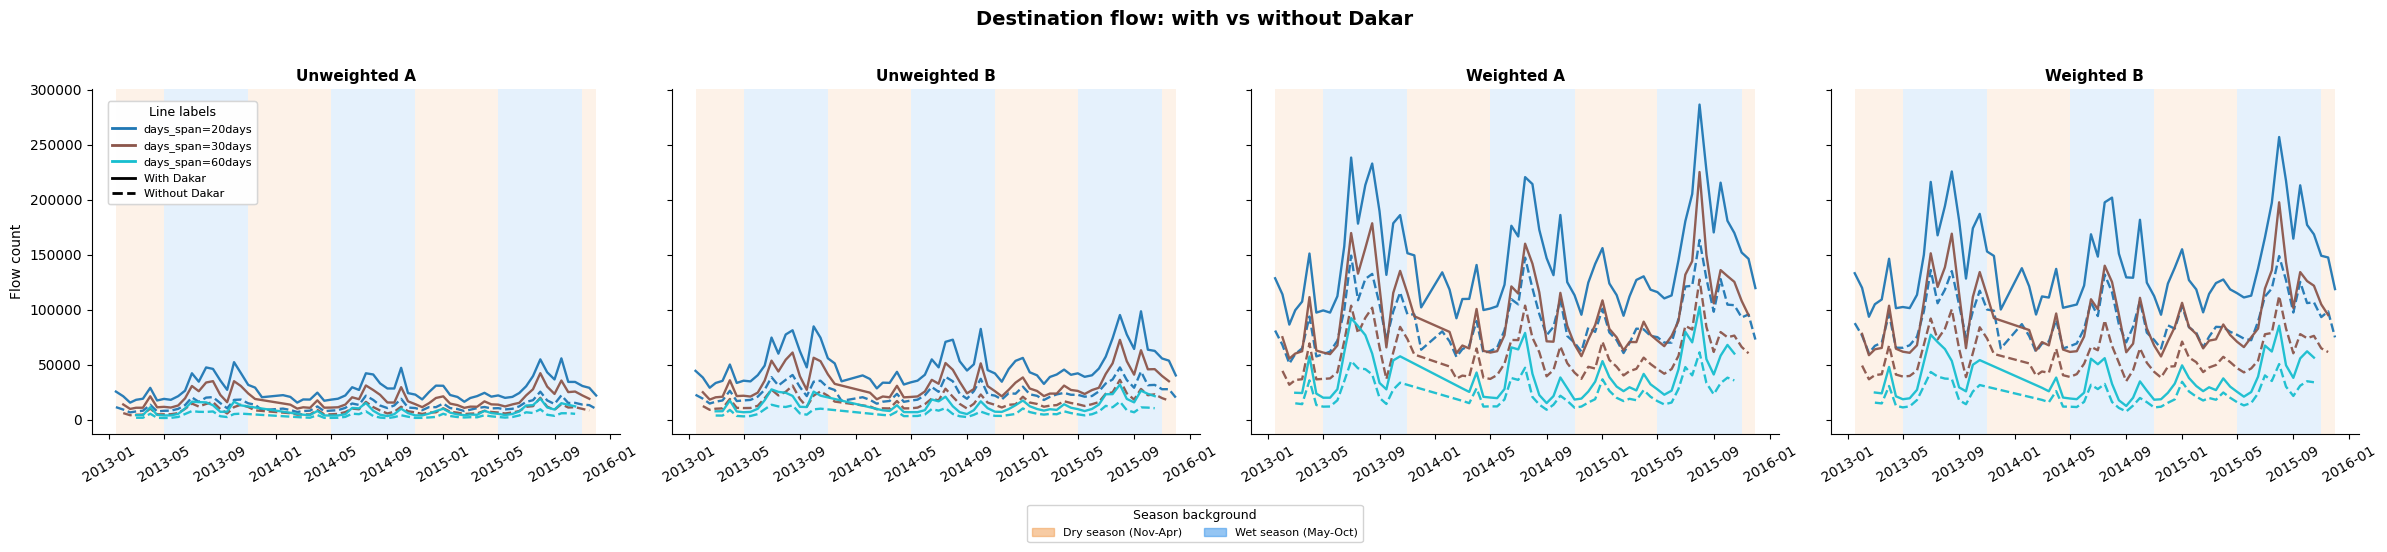

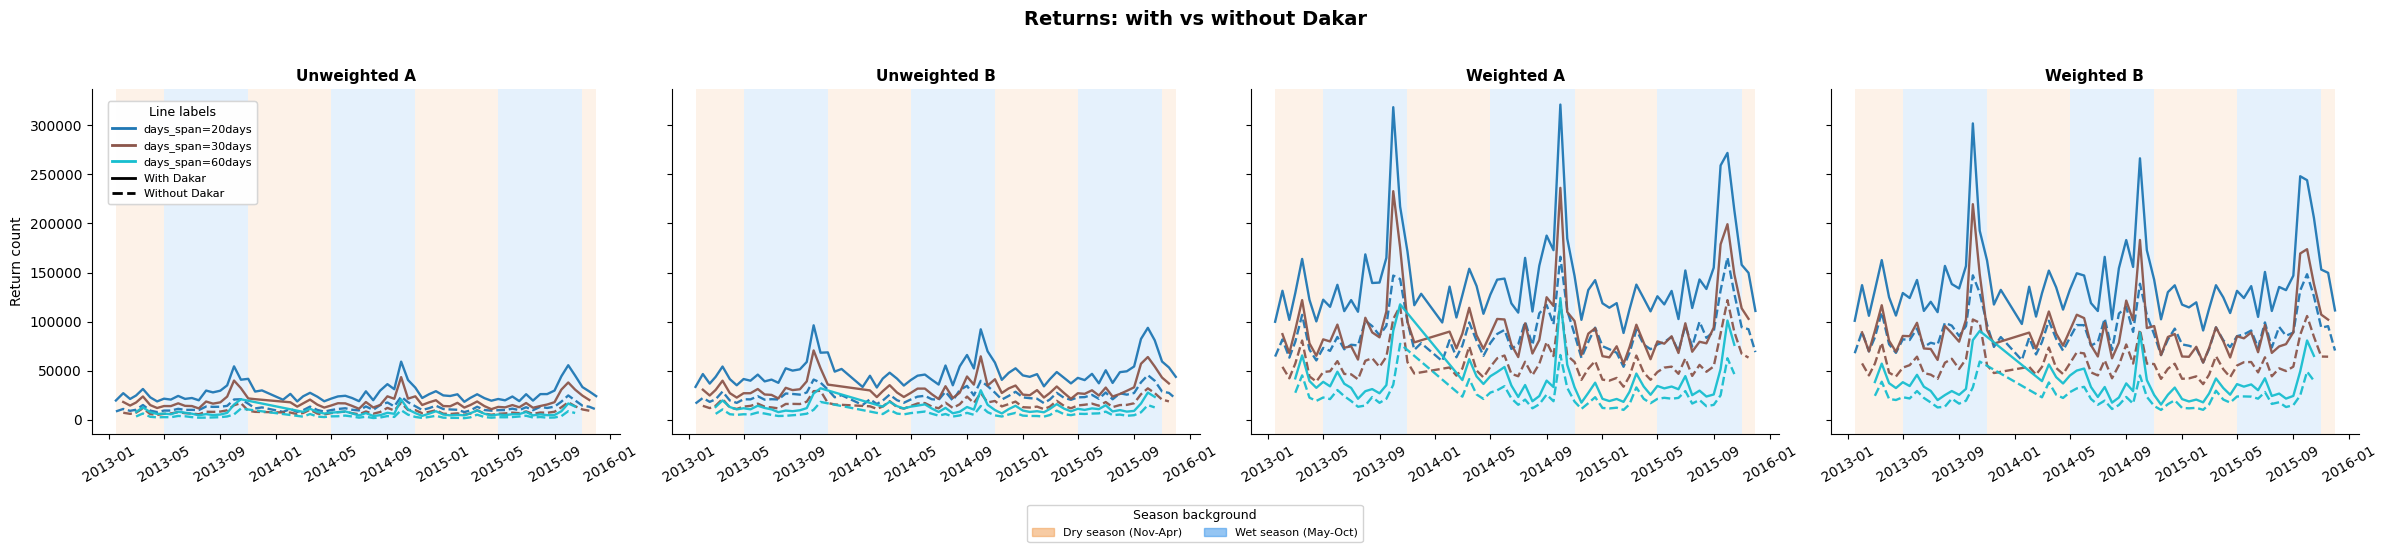

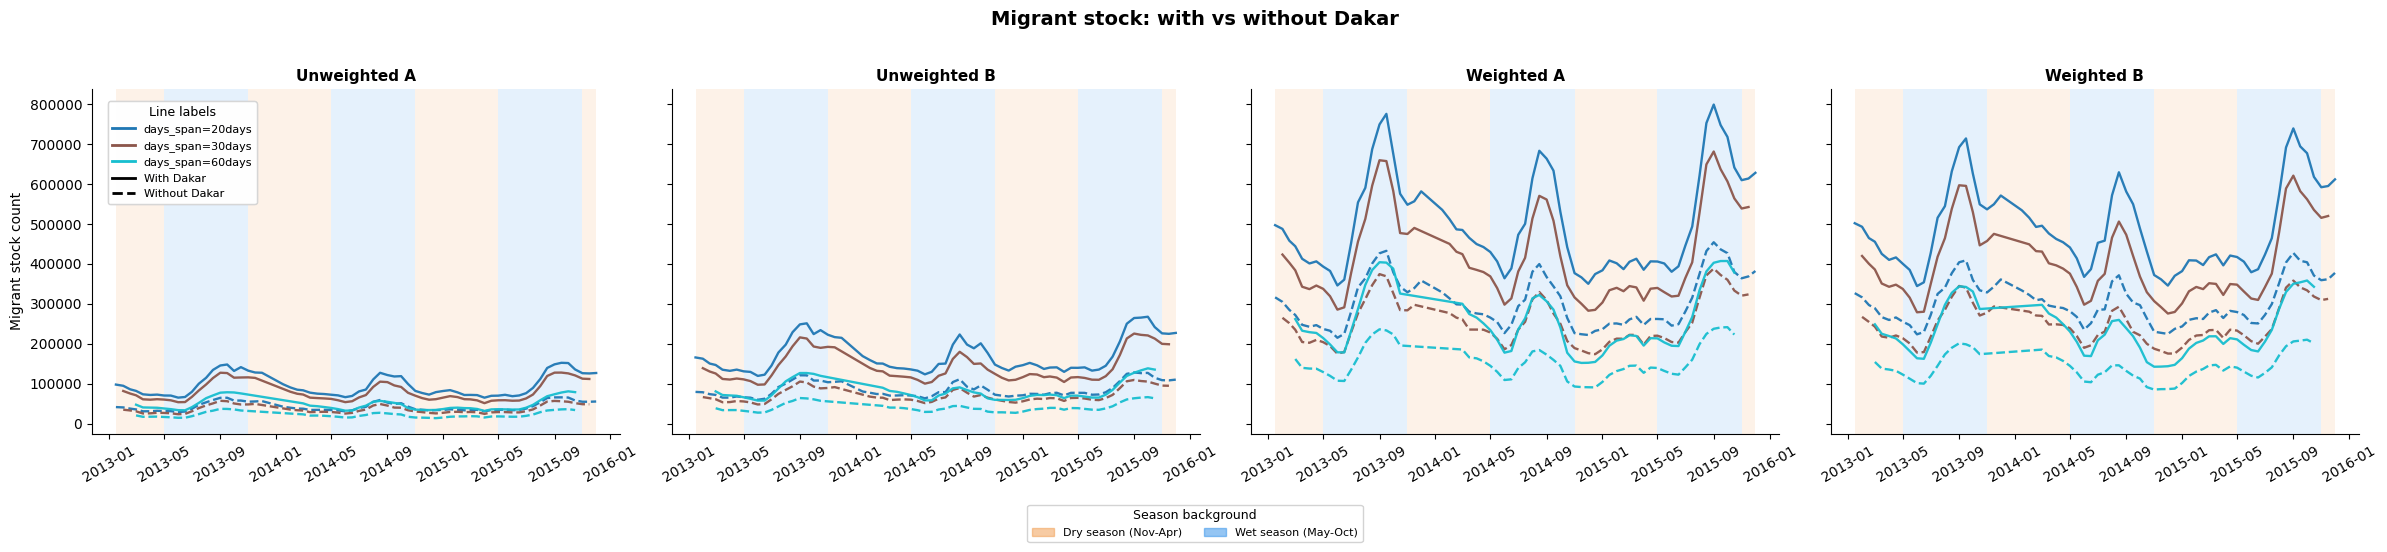

In [ ]:

# One figure per metric
for metric, cfg in metrics.items():

    ncols = len(col_keys)

    fig, axes = plt.subplots(
        1,
        ncols,
        figsize=(6 * ncols, 4.8),
        sharex=True,
        sharey=True
    )

    axes = np.atleast_1d(axes)

    for c, col_key in enumerate(col_keys):

        ax = axes[c]

        # Season background based on available dates
        season_df = pd.concat([
            add_season(dakar_variants['with_dakar'][col_key])[['date', 'season']],
            add_season(dakar_variants['without_dakar'][col_key])[['date', 'season']]
        ], ignore_index=True).drop_duplicates('date').sort_values('date')

        if not season_df.empty:
            axvspan_seasons(ax, season_df)

        has_data = False

        for ds in days_spans:

            # With Dakar
            df_with = aggregate_metric(
                dakar_variants['with_dakar'][col_key],
                ds,
                metric
            )

            if not df_with.empty:
                ax.plot(
                    df_with['date'],
                    df_with['value'],
                    color=days_colors[ds],
                    linestyle='-',
                    linewidth=1.7,
                    alpha=0.95,
                    zorder=2
                )
                has_data = True

            # Without Dakar
            df_without = aggregate_metric(
                dakar_variants['without_dakar'][col_key],
                ds,
                metric
            )

            if not df_without.empty:
                ax.plot(
                    df_without['date'],
                    df_without['value'],
                    color=days_colors[ds],
                    linestyle='--',
                    linewidth=1.7,
                    alpha=0.95,
                    zorder=2
                )
                has_data = True

        if not has_data:
            ax.set_visible(False)
            continue

        ax.set_title(col_labels[c], fontsize=11, fontweight='bold')
        ax.tick_params(axis='x', rotation=30)
        ax.spines[['top', 'right']].set_visible(False)

        if c == 0:
            ax.set_ylabel(cfg['ylabel'], fontsize=10)

    # Legend for days_span colors
    days_handles = [
        Line2D(
            [0], [0],
            color=days_colors[ds],
            linewidth=2,
            label=f'days_span={ds}'
        )
        for ds in days_spans
    ]

    # Legend for Dakar comparison
    dakar_handles = [
        Line2D([0], [0], color='black', linestyle='-', linewidth=2, label='With Dakar'),
        Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Without Dakar')
    ]

    # Put line legend inside first subplot, upper-left
    legend_ax = axes[0]

    line_legend = legend_ax.legend(
        handles=days_handles + dakar_handles,
        title='Line labels',
        loc='upper left',
        bbox_to_anchor=(0.02, 0.98),
        bbox_transform=legend_ax.transAxes,
        ncol=1,
        fontsize=8,
        title_fontsize=9,
        frameon=True,
        framealpha=0.85,
        facecolor='white',
        edgecolor='lightgray'
    )

    legend_ax.add_artist(line_legend)

    # Optional season legend at bottom
    season_patches = [
        mpatches.Patch(
            color=season_colors[s],
            alpha=0.5,
            label=season_labels[s]
        )
        for s in sorted(season_colors)
    ]

    fig.legend(
        handles=season_patches,
        title='Season background',
        loc='lower center',
        ncol=4,
        bbox_to_anchor=(0.5, -0.1),
        fontsize=8,
        title_fontsize=9,
        framealpha=0.85
    )

    fig.suptitle(
        f'{cfg["title"]}: with vs without Dakar',
        fontsize=14,
        fontweight='bold',
        y=1.02
    )
    plt.tight_layout()
    plt.savefig(
        f'mobility_{cfg["filename"]}_with_without_dakar.png',
        dpi=500,
        bbox_inches='tight'
    )
    plt.show()

In [ ]:

# # CHECK THE UNIQUE DATES IN THE 'date' COLUMN
# unique_dates = mob_data['date'].unique()
# print("Unique dates in the 'date' column:")
# print(len(unique_dates))
# # for date in unique_dates:
# #     # print date in order to check if the conversion is correct
# #     print(date)

# summary = (unweighted_a.groupby('days_span').agg(
#     rows = ("origin", "size"),
#     n_origin = ("origin", "nunique"),
#     n_destination = ("destination", "nunique"),
#     n_date = ("date", "nunique"),
#     total_departures = ("N_depart", "sum"),
#     total_returns = ("N_return", "sum"), 
#     total_stock = ("N_migrants", "sum")
# ).reset_index()
# )
# summary


# print summary for each subset and dakar variant and differences between with and without dakar
for dakar_key, subset_dict in dakar_variants.items():
    print(f"Summary for {dakar_key}:")
    for col_key in col_keys:
        df = subset_dict[col_key]
        summary = (df.groupby('days_span').agg(
            rows = ("origin_name", "size"),
            n_origin = ("origin_name", "nunique"),
            n_destination = ("destination_name", "nunique"),
            n_date = ("date", "nunique"),
            total_departures = ("N_depart", "sum"),
            total_returns = ("N_return", "sum"), 
            total_stock = ("N_migrants", "sum")
        ).reset_index())
        print(f"  Subset: {col_key}")
        print(summary)

# summary_diff = {}
# for col_key in col_keys:
#     with_dakar = dakar_variants['with_dakar'][col_key]
#     without_dakar = dakar_variants['without_dakar'][col_key]
    
#     summary_with = (with_dakar.groupby('days_span').agg(
#         total_departures = ("N_depart", "sum"),
#         total_returns = ("N_return", "sum"), 
#         total_stock = ("N_migrants", "sum")
#     ).reset_index())
    
#     summary_without = (without_dakar.groupby('days_span').agg(
#         total_departures = ("N_depart", "sum"),
#         total_returns = ("N_return", "sum"), 
#         total_stock = ("N_migrants", "sum")
#     ).reset_index())
    
#     diff = summary_with.set_index('days_span') - summary_without.set_index('days_span')
#     summary_diff[col_key] = diff.reset_index()
#     print(f"Difference for {col_key} (with Dakar - without Dakar):")
#     print(summary_diff[col_key])

### Rural-Urban Mobility - Testing only for Weighted A

In [5]:
# weighted_a = subsets['weighted_a']
# weighted_a["origin_type"] = np.where(weighted_a["origin"].str.startswith("city-"), "urban", "rural")
# weighted_a["destination_type"] = np.where(weighted_a["destination"].str.startswith("city-"), "urban", "rural")

# weighted_a["flow_type"] = weighted_a["origin_type"] + " → " + weighted_a["destination_type"]
# weighted_a
mob_data["origin_type"] = np.where(mob_data["origin"].str.startswith("city-"), "urban", "rural")
mob_data["destination_type"] = np.where(mob_data["destination"].str.startswith("city-"), "urban", "rural")
mob_data["flow_type"] = mob_data["origin_type"] + " → " + mob_data["destination_type"]
mob_data

,origin,destination,HalfMonthIndex,N_depart,N_return,rate_depart,rate_return,N_users_observed_depart,N_users_observed_return,N_migrants,...,subset_type,days_span,norm_spatial_id_origin,norm_spatial_id_destination,origin_name,destination_name,date,origin_type,destination_type,flow_type
0,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130301,0.0,0.0,0.000000,0.0,2091.0,2091.0,0.0,...,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-03-01,rural,rural,rural → rural
1,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130316,0.0,0.0,0.000000,0.0,2090.0,2091.0,0.0,...,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-03-16,rural,rural,rural → rural
2,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130401,0.0,0.0,0.000000,0.0,2091.0,2089.0,0.0,...,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-04-01,rural,rural,rural → rural
3,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130416,0.0,0.0,0.000000,0.0,2092.0,2091.0,0.0,...,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-04-16,rural,rural,rural → rural
4,SEN.14.3.1_1-rural,SEN.6.3.2_1-rural,20130501,0.0,0.0,0.000000,0.0,2100.0,2091.0,0.0,...,A,60days,sen.14.3.1,sen.6.3.2,Niaguis-rural,Sabodala-rural,2013-05-01,rural,rural,rural → rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17032795,city-008,city-017,20151001,0.0,0.0,0.000000,0.0,1949.0,1952.0,0.0,...,A,20days,city-008,city-017,Diaobé,Kébémer,2015-10-01,urban,urban,urban → urban
17032796,city-008,city-017,20151016,0.0,0.0,0.000000,0.0,1938.0,1949.0,0.0,...,A,20days,city-008,city-017,Diaobé,Kébémer,2015-10-16,urban,urban,urban → urban
17032797,city-008,city-017,20151101,0.0,0.0,0.000000,0.0,1933.0,1940.0,0.0,...,A,20days,city-008,city-017,Diaobé,Kébémer,2015-11-01,urban,urban,urban → urban
17032798,city-008,city-017,20151116,0.0,0.0,0.000000,0.0,1924.0,1933.0,0.0,...,A,20days,city-008,city-017,Diaobé,Kébémer,2015-11-16,urban,urban,urban → urban


In [96]:
flow_type_summary = (mob_data.groupby(['days_span', 'flow_type'], as_index=False).agg(
    departures=('N_depart', 'sum'),
    returns=('N_return', 'sum'),
    migration_stock=('N_migrants', 'sum'),
).sort_values(['days_span', 'flow_type'], ascending=[True, False]))

flow_type_summary
# without__dakar

flow_type_summary_without_dakar = (drop_dakar(mob_data).groupby(['days_span', 'flow_type'], as_index=False).agg(
    departures=('N_depart', 'sum'),
    returns=('N_return', 'sum'),
    migration_stock=('N_migrants', 'sum'),
).sort_values(['days_span', 'flow_type'], ascending=[True, False])) 
flow_type_summary_without_dakar

,days_span,flow_type,departures,returns,migration_stock
3,20days,urban → urban,1.886278e+06,1.859113e+06,6.555900e+06
2,20days,urban → rural,3.130441e+06,3.028460e+06,1.066578e+07
1,20days,rural → urban,3.954038e+06,3.936647e+06,1.377755e+07
0,20days,rural → rural,5.704207e+06,5.654090e+06,1.909610e+07
7,30days,urban → urban,1.179030e+06,1.161269e+06,5.105195e+06
6,30days,urban → rural,1.991473e+06,1.883552e+06,8.373882e+06
5,30days,rural → urban,2.430594e+06,2.449060e+06,1.067743e+07
4,30days,rural → rural,3.492434e+06,3.476735e+06,1.473090e+07
11,60days,urban → urban,4.298755e+05,4.161755e+05,2.643795e+06
10,60days,urban → rural,7.359952e+05,6.440481e+05,4.275828e+06


In [ ]:
from IPython.display import display

flow_direction_labels = {
    'rural → urban': 'Rural → Urban',
    'urban → rural': 'Urban → Rural',
}

flow_type_tables = {}

for subset in ['A', 'B']:
    for ds in ['20days', '30days', '60days']:
        df = mob_data[
            (mob_data['subset_type'] == subset) &
            (mob_data['days_span'] == ds) &
            (mob_data['flow_type'].isin(flow_direction_labels))
        ].copy()

        if df.empty:
            continue

        depart_total = df['N_depart'].sum()
        return_total = df['N_return'].sum()
        stock_total = df['N_migrants'].sum()

        table = (
            df.groupby('flow_type', as_index=False)
            .agg(
                total_departures=('N_depart', 'sum'),
                total_returns=('N_return', 'sum'),
                total_stock=('N_migrants', 'sum'),
                pop_observed=('pop_observed', 'max'),
                N_users_observed_depart=('N_users_observed_depart', 'max'),
                N_users_observed_return=('N_users_observed_return', 'max'),
            )
            .assign(
                flow_type=lambda frame: frame['flow_type'].map(flow_direction_labels).fillna(frame['flow_type']),
                share_departures=lambda frame: frame['total_departures'] / depart_total if depart_total else np.nan,
                share_returns=lambda frame: frame['total_returns'] / return_total if return_total else np.nan,
                share_stock=lambda frame: frame['total_stock'] / stock_total if stock_total else np.nan,
            )
            .sort_values('flow_type')
        )

        flow_type_tables[(subset, ds)] = table

        print(f'Subset {subset}, days_span {ds}')
        display(table)


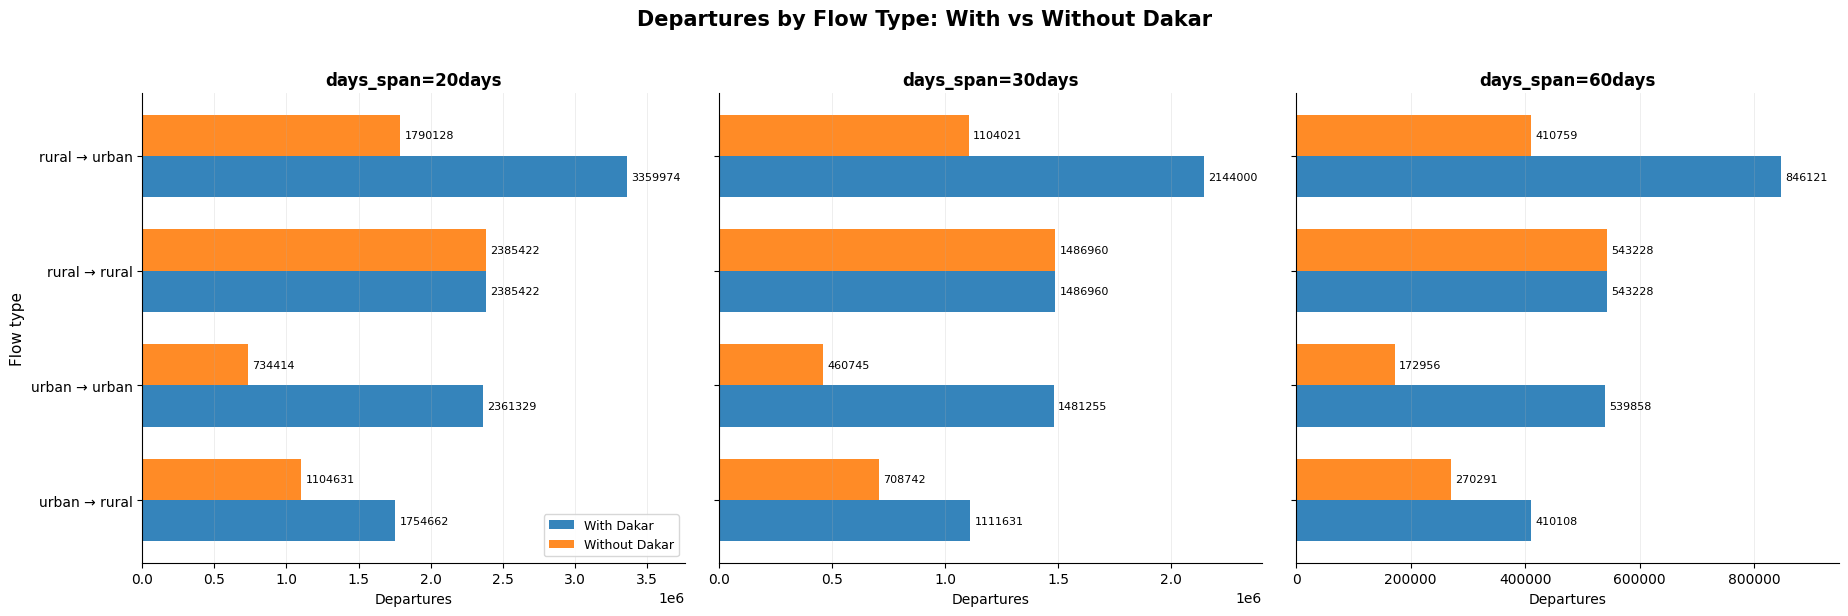

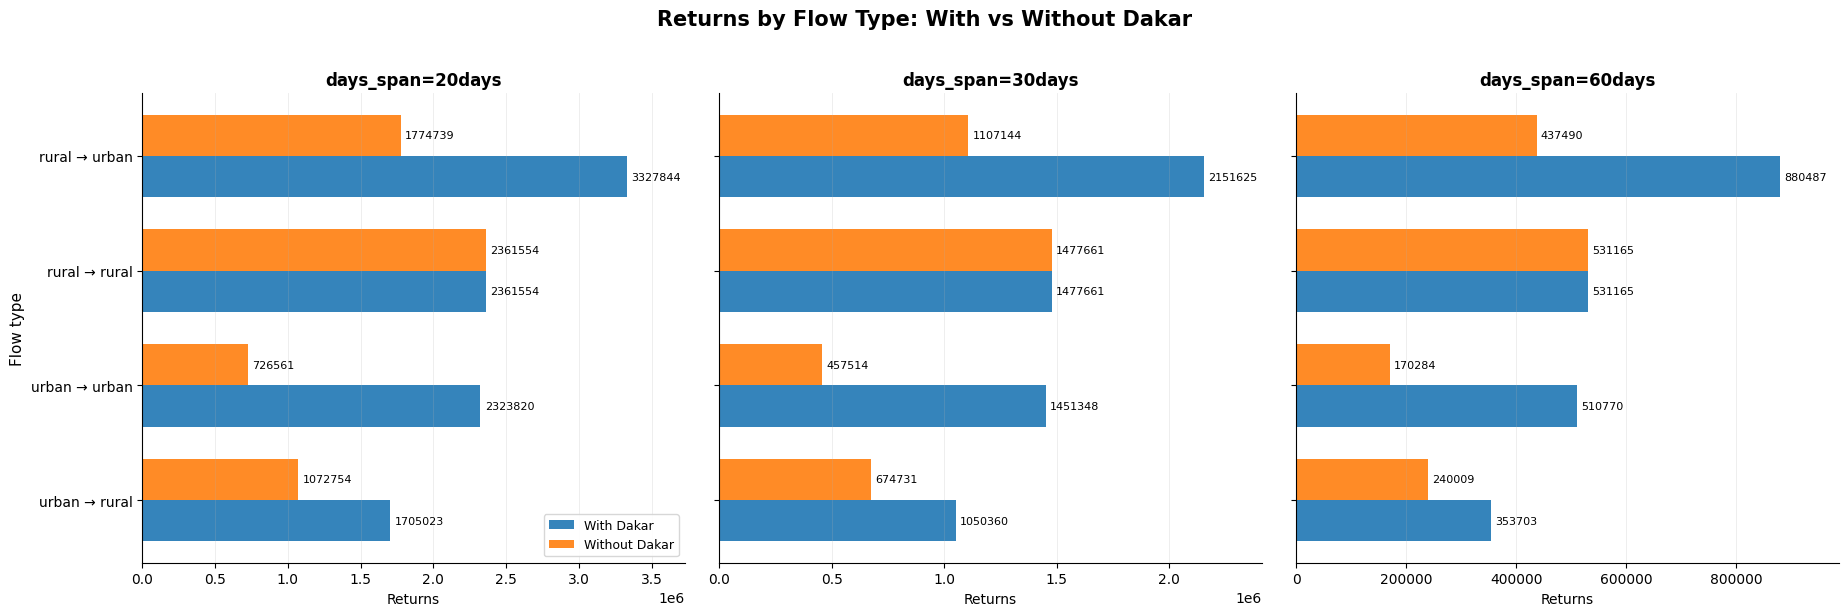

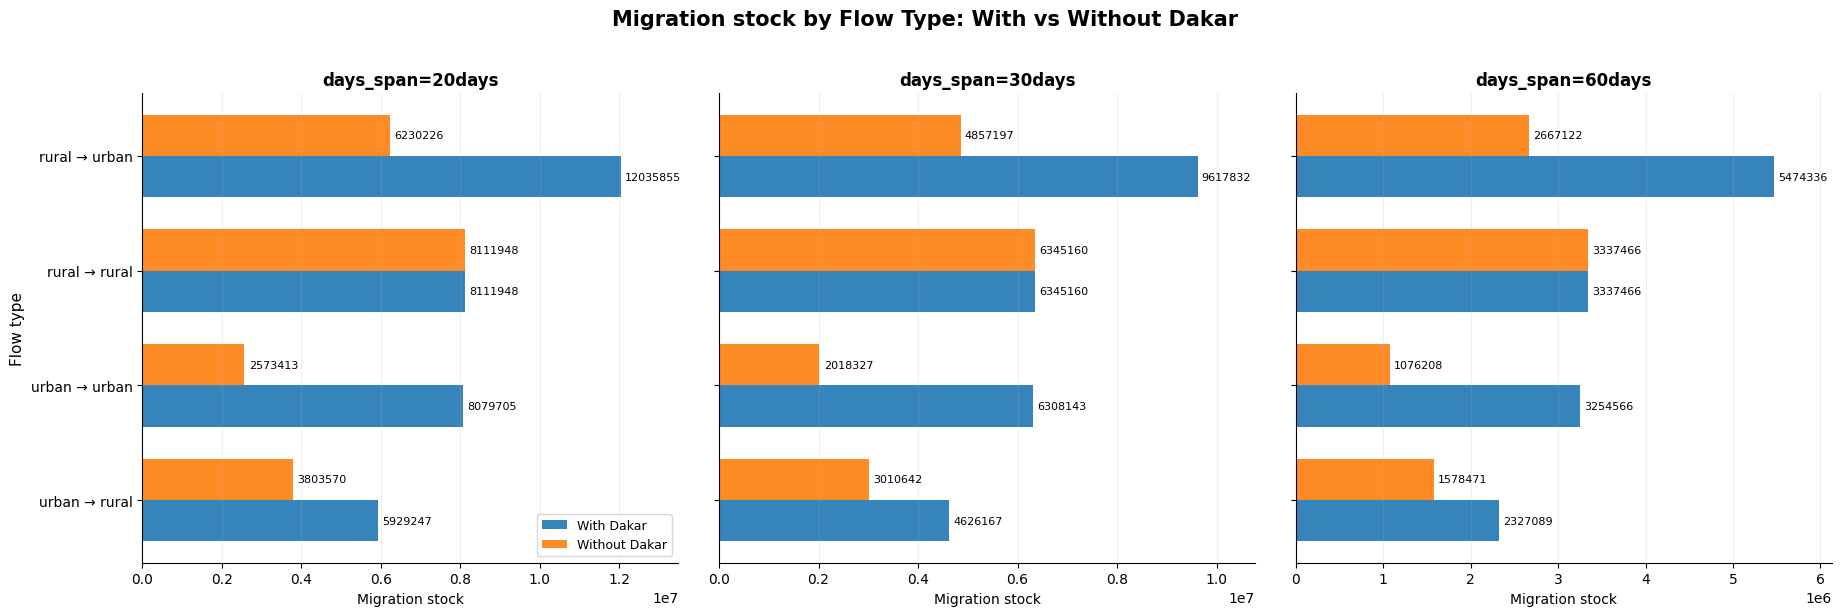

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --------------------------------------------------
# 1. Add labels and combine both summaries
# --------------------------------------------------

flow_with = flow_type_summary.copy()
flow_with['dakar_status'] = 'With Dakar'

flow_without = flow_type_summary_without_dakar.copy()
flow_without['dakar_status'] = 'Without Dakar'

flow_compare = pd.concat([flow_with, flow_without], ignore_index=True)

# Make sure days_span is sorted
days_spans = sorted(flow_compare['days_span'].dropna().unique())

metrics = {
    'departures': 'Departures',
    'returns': 'Returns',
    'migration_stock': 'Migration stock'
}

# Colors
colors = {
    'With Dakar': '#1f77b4',
    'Without Dakar': '#ff7f0e'
}

# --------------------------------------------------
# 2. Plot one figure per metric
# --------------------------------------------------

for metric, metric_label in metrics.items():

    ncols = len(days_spans)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=ncols,
        figsize=(6.2 * ncols, 6),
        sharey=True
    )

    axes = np.atleast_1d(axes)

    for i, ds in enumerate(days_spans):

        ax = axes[i]

        df_ds = flow_compare[flow_compare['days_span'] == ds].copy()

        if df_ds.empty:
            ax.set_visible(False)
            continue

        # Order flow types by total value
        flow_order = (
            df_ds
            .groupby('flow_type')[metric]
            .sum()
            .sort_values(ascending=True)
            .index
            .tolist()
        )

        pivot = (
            df_ds
            .pivot_table(
                index='flow_type',
                columns='dakar_status',
                values=metric,
                aggfunc='sum',
                fill_value=0
            )
            .reindex(flow_order)
        )

        # Ensure both columns exist
        for col in ['With Dakar', 'Without Dakar']:
            if col not in pivot.columns:
                pivot[col] = 0

        y = np.arange(len(pivot))
        height = 0.36

        ax.barh(
            y - height / 2,
            pivot['With Dakar'],
            height,
            label='With Dakar',
            color=colors['With Dakar'],
            alpha=0.90
        )

        ax.barh(
            y + height / 2,
            pivot['Without Dakar'],
            height,
            label='Without Dakar',
            color=colors['Without Dakar'],
            alpha=0.90
        )

        ax.set_title(
            f'days_span={ds}',
            fontsize=12,
            fontweight='bold'
        )

        ax.set_yticks(y)
        ax.set_yticklabels(pivot.index, fontsize=10)

        ax.set_xlabel(metric_label, fontsize=10)

        ax.grid(axis='x', alpha=0.25, linewidth=0.6)
        ax.spines[['top', 'right']].set_visible(False)
        ax.margins(x=0.12)

        # Optional value labels
        for container in ax.containers:
            ax.bar_label(
                container,
                fmt='%.0f',
                padding=3,
                fontsize=8
            )

        if i == 0:
            ax.set_ylabel('Flow type', fontsize=11)

    # Shared legend inside top-left of first subplot
    axes[0].legend(
        loc='lower right',
        fontsize=9,
        frameon=True,
        framealpha=0.9,
        facecolor='white',
        edgecolor='lightgray'
    )

    fig.suptitle(
        f'{metric_label} by Flow Type: With vs Without Dakar',
        fontsize=15,
        fontweight='bold',
        y=1.02
    )

    plt.tight_layout()

    plt.savefig(
        f'flow_type_{metric}_with_without_dakar.png',
        dpi=500,
        bbox_inches='tight'
    )

    plt.show()

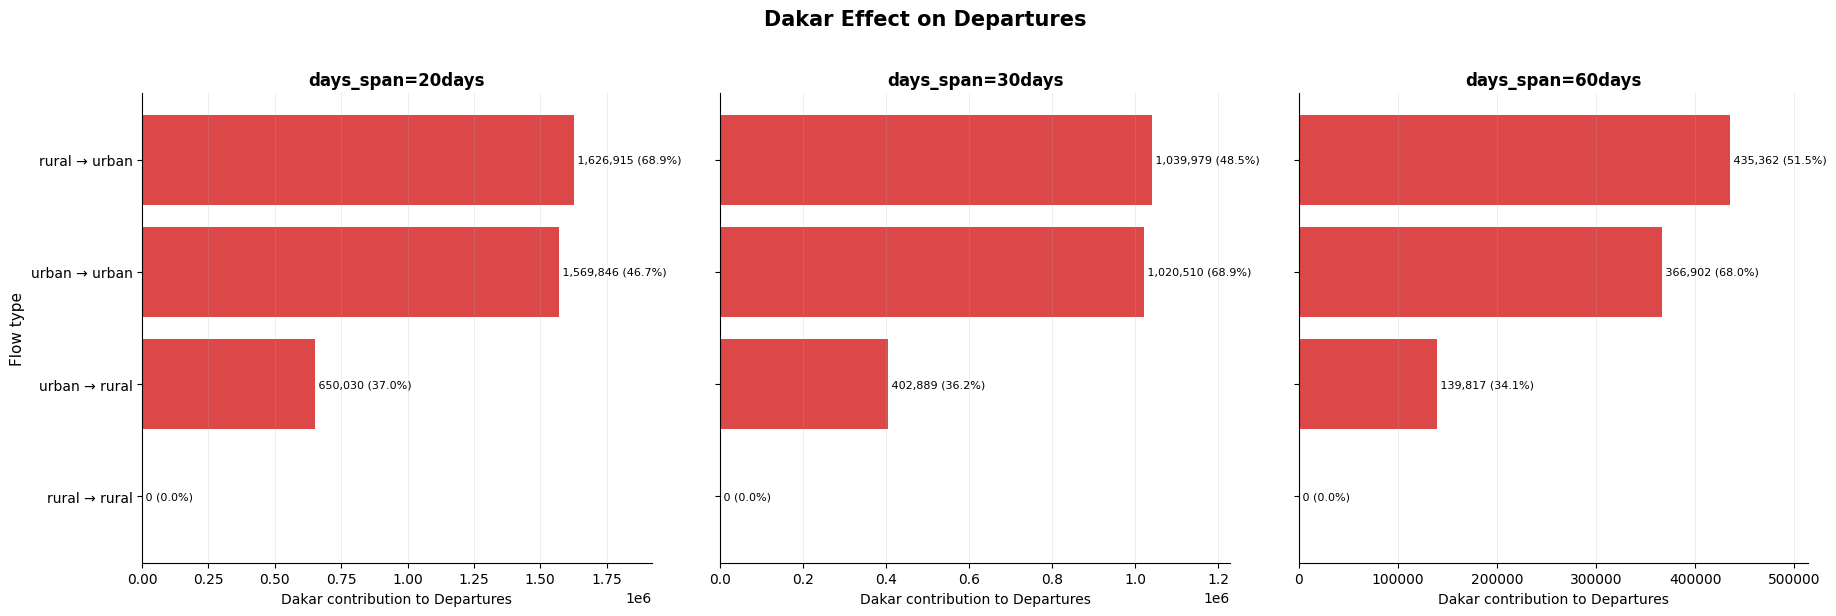

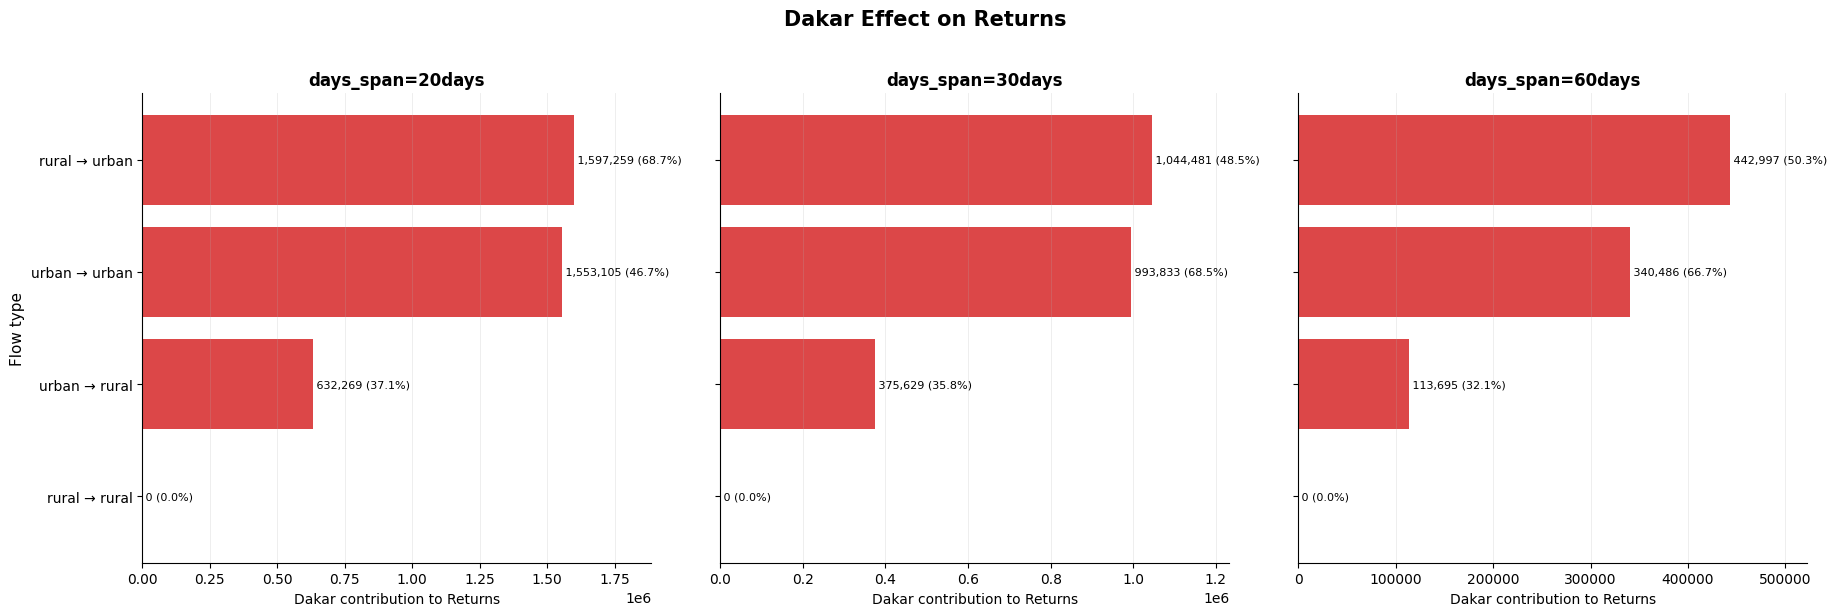

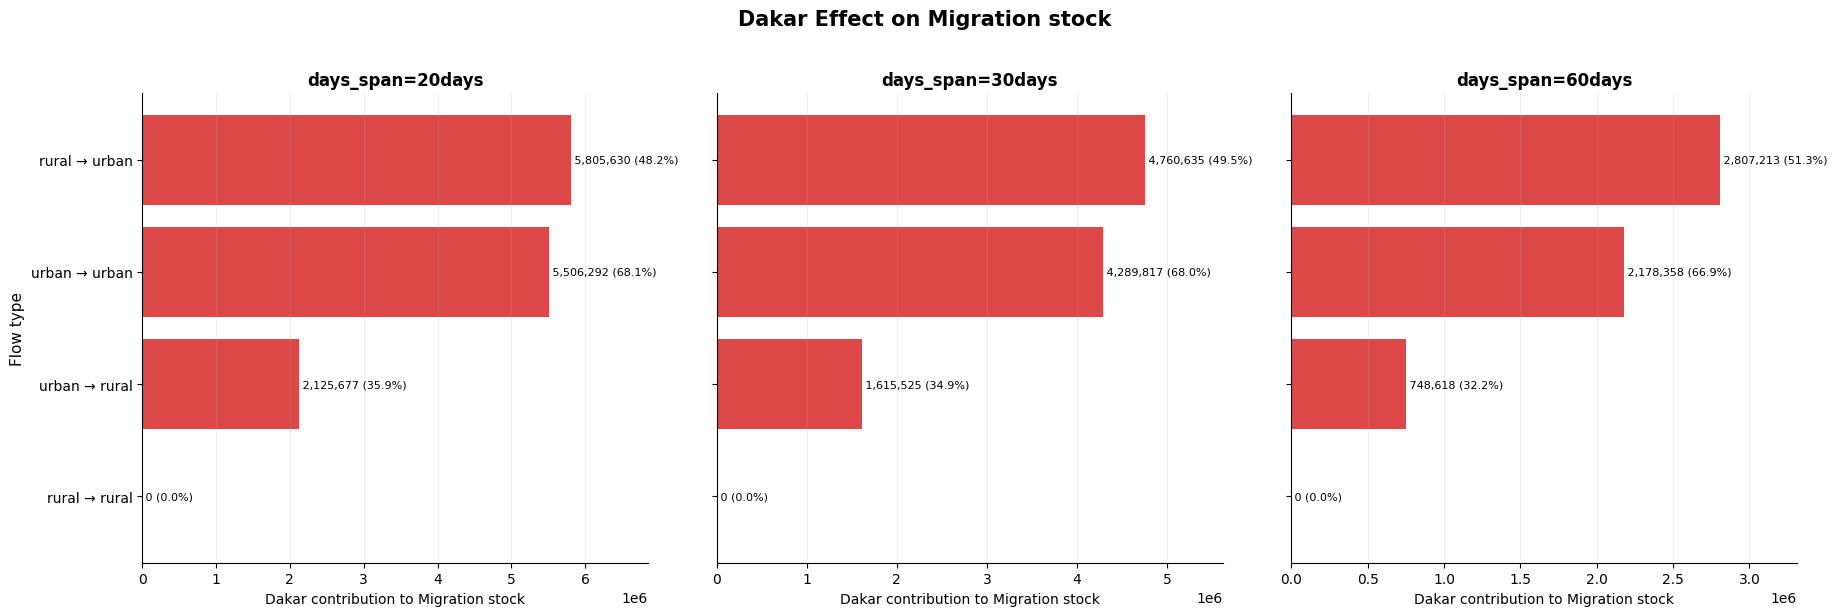

In [19]:
# --------------------------------------------------
# 3. Dakar effect plot: With Dakar - Without Dakar
# --------------------------------------------------

with_df = flow_type_summary.copy()
without_df = flow_type_summary_without_dakar.copy()

compare_effect = with_df.merge(
    without_df,
    on=['days_span', 'flow_type'],
    suffixes=('_with', '_without'),
    how='outer'
).fillna(0)

for metric, metric_label in metrics.items():

    compare_effect[f'{metric}_dakar_effect'] = (
        compare_effect[f'{metric}_with'] -
        compare_effect[f'{metric}_without']
    )

    compare_effect[f'{metric}_dakar_share_pct'] = np.where(
        compare_effect[f'{metric}_with'] > 0,
        compare_effect[f'{metric}_dakar_effect'] / compare_effect[f'{metric}_with'] * 100,
        0
    )


for metric, metric_label in metrics.items():

    effect_col = f'{metric}_dakar_effect'
    pct_col = f'{metric}_dakar_share_pct'

    ncols = len(days_spans)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=ncols,
        figsize=(6.2 * ncols, 6),
        sharey=True
    )

    axes = np.atleast_1d(axes)

    for i, ds in enumerate(days_spans):

        ax = axes[i]

        df_ds = compare_effect[compare_effect['days_span'] == ds].copy()

        if df_ds.empty:
            ax.set_visible(False)
            continue

        df_ds = df_ds.sort_values(effect_col, ascending=True)

        y = np.arange(len(df_ds))

        bars = ax.barh(
            y,
            df_ds[effect_col],
            color='#d62728',
            alpha=0.85
        )

        ax.set_yticks(y)
        ax.set_yticklabels(df_ds['flow_type'], fontsize=10)

        ax.set_xlabel(f'Dakar contribution to {metric_label}', fontsize=10)

        ax.set_title(
            f'days_span={ds}',
            fontsize=12,
            fontweight='bold'
        )

        ax.grid(axis='x', alpha=0.25, linewidth=0.6)
        ax.spines[['top', 'right']].set_visible(False)
        ax.margins(x=0.18)

        # Add labels with count and %
        for bar, pct in zip(bars, df_ds[pct_col]):
            width = bar.get_width()

            ax.text(
                width,
                bar.get_y() + bar.get_height() / 2,
                f' {width:,.0f} ({pct:.1f}%)',
                va='center',
                fontsize=8
            )

        if i == 0:
            ax.set_ylabel('Flow type', fontsize=11)

    fig.suptitle(
        f'Dakar Effect on {metric_label}',
        fontsize=15,
        fontweight='bold',
        y=1.02
    )

    plt.tight_layout()

    plt.savefig(
        f'dakar_effect_{metric}.png',
        dpi=500,
        bbox_inches='tight'
    )

    plt.show()

### Identify cities with largest change

In [6]:
# create weighted and unweighted subsets
weighted = mob_data[mob_data['weight_type'] == 'weighted']
unweighted = mob_data[mob_data['weight_type'] == 'unweighted']
print(f"Weighted subset: {len(weighted)} records")
print(f"Unweighted subset: {len(unweighted)} records")
origin_ts = (
    weighted.groupby(["days_span", "origin", "date"], as_index=False)
    .agg(
        out_departures=("N_depart", "sum"),
        returns_home=("N_return", "sum"),
        migrant_stock_out=("N_migrants", "sum"),
    )
)

origin_ts["origin_type"] = np.where(
    origin_ts["origin"].str.startswith("city-"),
    "urban",
    "rural"
)
# use orgin name instead of origin code
origin_ts = origin_ts.merge(
    mob_data[["origin", "origin_name"]].drop_duplicates(),
    on="origin",
    how="left"
)
origin_ts

Weighted subset: 8516400 records
Unweighted subset: 8516400 records


,days_span,origin,date,out_departures,returns_home,migrant_stock_out,origin_type,origin_name
0,20days,SEN.1.1.1_1-rural,2013-01-16,1839.956778,1286.830216,7250.995974,rural,Dakar-rural
1,20days,SEN.1.1.1_1-rural,2013-02-01,1701.575987,1820.315349,7639.765880,rural,Dakar-rural
2,20days,SEN.1.1.1_1-rural,2013-02-16,1120.454399,1489.636554,7142.796176,rural,Dakar-rural
3,20days,SEN.1.1.1_1-rural,2013-03-01,1461.155315,1931.214573,6999.069072,rural,Dakar-rural
4,20days,SEN.1.1.1_1-rural,2013-03-16,1391.746892,2526.589017,6419.108997,rural,Dakar-rural
...,...,...,...,...,...,...,...,...
28383,60days,city-054,2015-08-16,3345.168453,768.972091,18223.612719,urban,Ziguinchor
28384,60days,city-054,2015-09-01,2454.979432,971.221724,20019.543205,urban,Ziguinchor
28385,60days,city-054,2015-09-16,2524.356384,1514.695025,21029.172359,urban,Ziguinchor
28386,60days,city-054,2015-10-01,3473.942529,4771.903130,21875.701685,urban,Ziguinchor


In [98]:
def largest_jump(df, value_col, unit_col="origin_name"):
    rows = []

    for (duration, unit), g in df.groupby(["days_span", unit_col]):
        g = g.sort_values("date").copy()
        g["change"] = g[value_col].diff()

        if g["change"].notna().any():
            idx = g["change"].abs().idxmax()

            rows.append({
                "duration_days": duration,
                "unit": unit,
                "metric": value_col,
                "from_date": g.loc[idx - 1, "date"] if idx - 1 in g.index else None,
                "to_date": g.loc[idx, "date"],
                "before": g[value_col].shift(1).loc[idx],
                "after": g.loc[idx, value_col],
                "change": g.loc[idx, "change"],
                "abs_change": abs(g.loc[idx, "change"]),
            })

    return pd.DataFrame(rows).sort_values("abs_change", ascending=False)

largest_departure_jumps = largest_jump(origin_ts, "out_departures")
largest_stock_jumps = largest_jump(origin_ts, "migrant_stock_out")

In [99]:
largest_departure_jumps.head(10)

,duration_days,unit,metric,from_date,to_date,before,after,change,abs_change
20,20days,Dakar,out_departures,2013-09-16,2013-10-01,33352.145010,110696.990871,77344.845861,77344.845861
171,30days,Dakar,out_departures,2013-09-16,2013-10-01,23550.493731,75933.265364,52382.771634,52382.771634
322,60days,Dakar,out_departures,2013-09-16,2013-10-01,12623.063224,35534.430122,22911.366898,22911.366898
143,20days,Tivaouane,out_departures,2013-08-01,2013-08-16,2608.032652,20953.058586,18345.025933,18345.025933
294,30days,Tivaouane,out_departures,2013-08-01,2013-08-16,1866.528329,19394.631561,17528.103232,17528.103232
144,20days,Touba,out_departures,2015-11-16,2015-12-01,3596.270491,20910.634922,17314.364431,17314.364431
116,20days,Rao-rural,out_departures,2014-07-01,2014-07-16,2259.358052,18514.837052,16255.479000,16255.479000
445,60days,Tivaouane,out_departures,2013-08-01,2013-08-16,912.217099,16034.628669,15122.411570,15122.411570
267,30days,Rao-rural,out_departures,2014-07-01,2014-07-16,1582.516433,16239.280624,14656.764192,14656.764192
4,20days,Bambey,out_departures,2014-07-01,2014-07-16,4056.415066,15870.813656,11814.398591,11814.398591


In [100]:
largest_stock_jumps.head(10)

,duration_days,unit,metric,from_date,to_date,before,after,change,abs_change
20,20days,Dakar,migrant_stock_out,2013-10-01,2013-10-16,136583.707191,233713.998996,97130.291805,97130.291805
171,30days,Dakar,migrant_stock_out,2013-10-01,2013-10-16,118791.143208,181365.324236,62574.181028,62574.181028
322,60days,Dakar,migrant_stock_out,2013-10-16,2014-03-01,106870.344762,65576.975565,-41293.369197,41293.369197
144,20days,Touba,migrant_stock_out,2014-11-16,2014-12-01,48967.443535,15382.782739,-33584.660796,33584.660796
295,30days,Touba,migrant_stock_out,2014-11-16,2014-12-01,36401.856350,12886.180302,-23515.676047,23515.676047
78,20days,Mboro,migrant_stock_out,2013-08-16,2013-09-01,23705.736124,510.139307,-23195.596817,23195.596817
229,30days,Mboro,migrant_stock_out,2013-08-16,2013-09-01,20735.312688,235.892760,-20499.419928,20499.419928
143,20days,Tivaouane,migrant_stock_out,2013-08-16,2013-09-01,7933.914055,27398.112395,19464.198340,19464.198340
294,30days,Tivaouane,migrant_stock_out,2013-08-16,2013-09-01,6696.681009,25350.291014,18653.610005,18653.610005
116,20days,Rao-rural,migrant_stock_out,2015-08-01,2015-08-16,12287.973415,30564.258078,18276.284663,18276.284663


### Identify strongest sender and receiver units

#### Strongest origins: out-migration pressure

In [7]:
top_origins = (
    origin_ts.groupby(["days_span", "origin", "origin_name", "origin_type"], as_index=False)
    .agg(
        total_departures=("out_departures", "sum"),
        total_returns=("returns_home", "sum"),
        total_stock_out=("migrant_stock_out", "sum"),
    )
    .sort_values(["days_span", "total_departures"], ascending=[True, False])
)

top_origins.groupby("days_span").head()

,days_span,origin,origin_name,origin_type,total_departures,total_returns,total_stock_out
116,20days,city-006,Dakar,urban,2.573254e+06,2.518853e+06,8.467392e+06
148,20days,city-050,Touba,urban,1.092665e+06,1.091429e+06,3.461483e+06
146,20days,city-048,Thiès,urban,4.101905e+05,3.978219e+05,1.463665e+06
150,20days,city-054,Ziguinchor,urban,4.066409e+05,3.959353e+05,1.430977e+06
123,20days,city-016,Kaolack,urban,3.893437e+05,3.720209e+05,1.302059e+06
267,30days,city-006,Dakar,urban,1.581488e+06,1.492240e+06,6.394530e+06
299,30days,city-050,Touba,urban,6.435740e+05,6.511506e+05,2.639844e+06
297,30days,city-048,Thiès,urban,2.679907e+05,2.571721e+05,1.167893e+06
301,30days,city-054,Ziguinchor,urban,2.656499e+05,2.528072e+05,1.130979e+06
274,30days,city-016,Kaolack,urban,2.470148e+05,2.316836e+05,1.016187e+06


#### Strongest destinations: hosted temporary migrants

In [8]:
destination_ts = (
    weighted.groupby(["days_span", "destination", "destination_name", "date"], as_index=False)
    .agg(
        inbound_departures=("N_depart", "sum"),
        inbound_returns=("N_return", "sum"),
        migrant_stock_in=("N_migrants", "sum"),
    )
)

top_destinations = (
    destination_ts.groupby(["days_span", "destination", "destination_name"], as_index=False)
    .agg(
        total_inbound_departures=("inbound_departures", "sum"),
        total_stock_in=("migrant_stock_in", "sum"),
    )
    .sort_values(["days_span", "total_inbound_departures"], ascending=[True, False])
)

top_destinations.groupby("days_span").head(10)

,days_span,destination,destination_name,total_inbound_departures,total_stock_in
116,20days,city-006,Dakar,4.824775e+06,1.750791e+07
148,20days,city-050,Touba,7.800663e+05,2.517175e+06
146,20days,city-048,Thiès,6.220615e+05,2.227743e+06
133,20days,city-028,MBour,5.646108e+05,2.019209e+06
123,20days,city-016,Kaolack,4.894903e+05,1.701476e+06
150,20days,city-054,Ziguinchor,3.961379e+05,1.370274e+06
141,20days,city-041,Saint-Louis,2.980578e+05,1.074807e+06
144,20days,city-046,Tambacounda,2.879601e+05,9.183363e+05
127,20days,city-021,Kolda,2.653665e+05,8.682007e+05
2,20days,SEN.10.1.2_1-rural,Ndiaye Mberess-rural,2.249897e+05,7.284891e+05


### Net mobility indicators

In [9]:
weighted_origin_total = (
    weighted.groupby(["days_span", "origin", "origin_name", "date"], as_index=False)
    .agg(
        out_departures=("N_depart", "sum"),
        stock_out=("N_migrants", "sum"),
    )
    .rename(columns={"origin_name": "unit"})
)

weighted_dest_total = (
    weighted.groupby(["days_span", "destination", "destination_name", "date"], as_index=False)
    .agg(
        in_departures=("N_depart", "sum"),
        stock_in=("N_migrants", "sum"),
    )
    .rename(columns={"destination_name": "unit"})
)

unit_panel = weighted_origin_total.merge(
    weighted_dest_total,
    on=["days_span", "unit", "date"],
    how="outer"
).fillna(0)

unit_panel["net_departure_flow"] = unit_panel["in_departures"] - unit_panel["out_departures"]
unit_panel["net_stock"] = unit_panel["stock_in"] - unit_panel["stock_out"]

unit_panel

,days_span,origin,unit,date,out_departures,stock_out,destination,in_departures,stock_in,net_departure_flow,net_stock
0,20days,SEN.9.2.1_1-rural,Agnam Civol-rural,2013-01-16,1534.523078,6408.925761,SEN.9.2.1_1-rural,1749.082499,5817.289444,214.559421,-591.636317
1,20days,SEN.9.2.1_1-rural,Agnam Civol-rural,2013-02-01,1592.847870,6392.779606,SEN.9.2.1_1-rural,1724.585548,5878.189025,131.737677,-514.590581
2,20days,SEN.9.2.1_1-rural,Agnam Civol-rural,2013-02-16,1475.745420,6203.612873,SEN.9.2.1_1-rural,1163.150998,5766.823920,-312.594421,-436.788953
3,20days,SEN.9.2.1_1-rural,Agnam Civol-rural,2013-03-01,1514.085866,6171.837637,SEN.9.2.1_1-rural,1269.259332,6023.398479,-244.826534,-148.439158
4,20days,SEN.9.2.1_1-rural,Agnam Civol-rural,2013-03-16,1929.454032,6539.855044,SEN.9.2.1_1-rural,1456.069628,5142.137401,-473.384404,-1397.717643
...,...,...,...,...,...,...,...,...,...,...,...
28383,60days,city-054,Ziguinchor,2015-08-16,3345.168453,18223.612719,city-054,2248.188168,16064.780608,-1096.980285,-2158.832111
28384,60days,city-054,Ziguinchor,2015-09-01,2454.979432,20019.543205,city-054,2367.285289,17665.554540,-87.694143,-2353.988664
28385,60days,city-054,Ziguinchor,2015-09-16,2524.356384,21029.172359,city-054,2647.542718,18739.366890,123.186334,-2289.805468
28386,60days,city-054,Ziguinchor,2015-10-01,3473.942529,21875.701685,city-054,3497.388715,18196.901146,23.446186,-3678.800540


Interpretation:

|Indicator|	Meaning|
|---|----|
out_departures| people leaving this unit
in_departures|people arriving to this unit from other origins
stock_out |	residents of this unit currently away
stock_in	|temporary migrants currently hosted in this unit
net_departure_flow	|positive = receiving more new departures than sending
net_stock	|positive = hosting more migrants than it sends

### Seasonal analysis

In [10]:
origin_ts["period_cdr"] = (
    (origin_ts["date"].dt.month - 1) * 2
    + np.where(origin_ts["date"].dt.day == 1, 1, 2)
)

seasonality = (
    origin_ts.groupby(["days_span", "period_cdr"], as_index=False)
    .agg(
        mean_departures=("out_departures", "mean"),
        mean_returns=("returns_home", "mean"),
        mean_stock=("migrant_stock_out", "mean"),
    )
)

seasonality

,days_span,period_cdr,mean_departures,mean_returns,mean_stock
0,20days,1,2059.363568,1562.061885,5071.912109
1,20days,2,1731.125855,1381.239246,6371.716770
2,20days,3,1556.403380,1717.463266,6221.908896
3,20days,4,1235.902817,1315.971691,5929.647793
4,20days,5,1440.891678,1638.652690,5966.042952
...,...,...,...,...,...
67,60days,20,625.743365,983.771310,3674.499614
68,60days,21,241.304815,384.777926,1972.948697
69,60days,22,249.844941,216.533531,1950.864386
70,60days,23,330.861840,348.202451,1959.222229


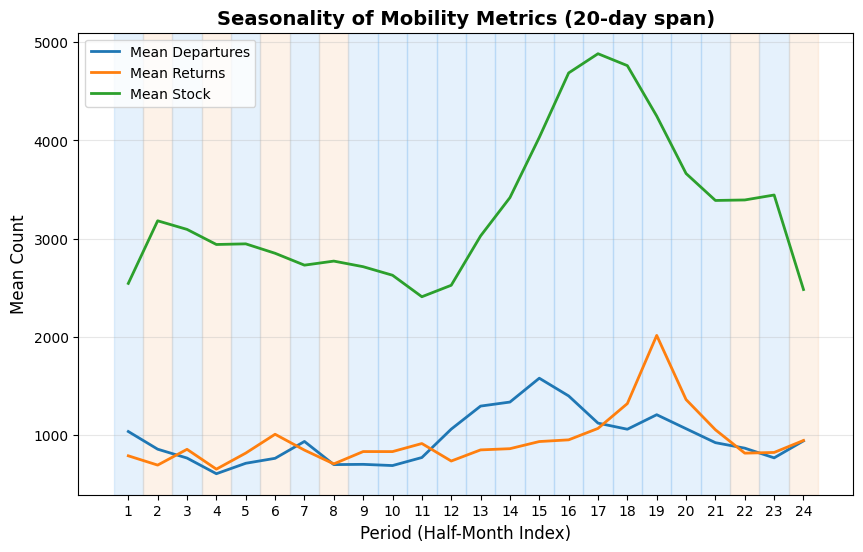

In [47]:
# can we put dry and wet season background in the plot? (Nov-Apr is dry, May-Oct is wet)

tmp = seasonality[seasonality["days_span"] == "20days"].sort_values("period_cdr")
plt.figure(figsize=(10, 6))
plt.plot(tmp["period_cdr"], tmp["mean_departures"], label="Mean Departures", color="#1f77b4", linewidth=2)
plt.plot(tmp["period_cdr"], tmp["mean_returns"], label="Mean Returns", color="#ff7f0e", linewidth=2)
plt.plot(tmp["period_cdr"], tmp["mean_stock"], label="Mean Stock", color="#2ca02c", linewidth=2)
plt.title("Seasonality of Mobility Metrics (20-day span)", fontsize=14, fontweight="bold")
plt.xlabel("Period (Half-Month Index)", fontsize=12)
plt.ylabel("Mean Count", fontsize=12)
plt.xticks(tmp["period_cdr"], tmp["period_cdr"].astype(int), rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="upper left", fontsize=10, framealpha=0.8)

# Add background shading for dry and wet seasons period wise
for period in tmp["period_cdr"].unique():
    if period in [11*2, 12*2, 1*2, 2*2, 3*2, 4*2]:  # Dry season
        plt.axvspan(period - 0.5, period + 0.5, color="#f09948", alpha=0.12)
    else:  # Wet season
        plt.axvspan(period - 0.5, period + 0.5, color="#2b8de9", alpha=0.12)

### Mobility anomaly

In [49]:
origin_ts["period_cdr"] = (
    (origin_ts["date"].dt.month - 1) * 2
    + np.where(origin_ts["date"].dt.day == 1, 1, 2)
)

clim_mob = (
    origin_ts.groupby(["days_span", "origin", "origin_name", "period_cdr"], as_index=False)
    .agg(
        normal_departures=("out_departures", "mean"),
        normal_returns=("returns_home", "mean"),
        normal_stock=("migrant_stock_out", "mean"),
    )
)

origin_ts = origin_ts.merge(
    clim_mob,
    on=["days_span", "origin", "origin_name", "period_cdr"],
    how="left"
)

origin_ts["departure_anomaly"] = origin_ts["out_departures"] - origin_ts["normal_departures"]
origin_ts["return_anomaly"] = origin_ts["returns_home"] - origin_ts["normal_returns"]
origin_ts["stock_anomaly"] = origin_ts["migrant_stock_out"] - origin_ts["normal_stock"]

In [58]:
# ## plot the anaomaly for departures, returns, and stock

# plt.figure(figsize=(12, 6))
# plt.plot(origin_ts["date"], origin_ts["departure_anomaly"], label="Departure Anomaly", color="#1f77b4", linewidth=1.5)
# plt.plot(origin_ts["date"], origin_ts["return_anomaly"], label="Return Anomaly", color="#ff7f0e", linewidth=1.5)
# plt.plot(origin_ts["date"], origin_ts["stock_anomaly"], label="Stock Anomaly", color="#2ca02c", linewidth=1.5)
# plt.title("Mobility Anomalies Over Time", fontsize=14, fontweight="bold")
# plt.xlabel("Date", fontsize=12)
# plt.ylabel("Anomaly Count", fontsize=12)
# plt.xticks(rotation=30)
# plt.grid(axis="y", alpha=0.3)
# plt.legend(loc="upper left", fontsize=10, framealpha=0.8)

# for period in origin_ts["period_cdr"].unique():
#     if period in [11*2, 12*2, 1*2, 2*2, 3*2, 4*2]:  # Dry season
#         plt.axvspan(
#             origin_ts[origin_ts["period_cdr"] == period]["date"].min(),
#             origin_ts[origin_ts["period_cdr"] == period]["date"].max(),
#             color="#f09948", alpha=0.12
#         )
#     else:  # Wet season
#         plt.axvspan(
#             origin_ts[origin_ts["period_cdr"] == period]["date"].min(),
#             origin_ts[origin_ts["period_cdr"] == period]["date"].max(),
#             color="#2b8de9", alpha=0.12
#         )

# plt.tight_layout()
# plt.show()

### OD matrix and top OD flows

In [59]:
# weighted_a

In [112]:
duration = "20days"

od = (
    weighted[weighted["days_span"] == duration]
    .groupby(["origin_name", "destination_name"], as_index=False)
    .agg(
        departures=("N_depart", "sum"),
        returns=("N_return", "sum"),
        migrant_stock=("N_migrants", "sum"),
    )
)

top_od = od.sort_values("departures", ascending=False)
top_od

,origin_name,destination_name,departures,returns,migrant_stock
21620,Touba,Dakar,393905.362534,396383.504581,1.223651e+06
21320,Thiès,Dakar,162651.799898,156671.086163,6.024921e+05
3141,Dakar,Thiès,145565.656589,143166.587681,5.164470e+05
7370,Kaolack,Dakar,143517.313204,136540.548542,4.785012e+05
22520,Ziguinchor,Dakar,139984.709704,134328.770428,5.293520e+05
...,...,...,...,...,...
13700,Ndiedieng-rural,Karantaba-rural,0.000000,0.000000,0.000000e+00
5326,Djilor-rural,Mbediene-rural,0.000000,0.000000,0.000000e+00
13673,Ndiedieng-rural,Dar Salam-rural,0.000000,0.000000,0.000000e+00
13822,Ndindy-rural,Dakately-rural,0.000000,0.000000,0.000000e+00


In [11]:

spatial_unit = gpd.read_parquet("/home/kzakir/dvcube/test/data/mobility_data/spatial_units.parquet")
spatial_unit

spatial_unit["lon"] = spatial_unit.geometry.centroid.x
spatial_unit["lat"] = spatial_unit.geometry.centroid.y

# # Make sure this ID matches origin/destination codes
# units = spatial_unit[["unit_id", "lon", "lat", "geometry"]]
spatial_unit

,id,name,zone_category,geometry,norm_id,lon,lat
0,SEN.1.1.1-rural,Dakar-rural,rural,"MULTIPOLYGON (((-17.14005 14.57827, -17.14034 ...",sen.1.1.1,-17.187838,14.751204
1,SEN.10.1.1-rural,Mbane-rural,rural,"MULTIPOLYGON (((-15.83737 16.21078, -15.87214 ...",sen.10.1.1,-15.585999,16.227448
2,SEN.10.1.2-rural,Ndiaye Mberess-rural,rural,"MULTIPOLYGON (((-16.26705 16.0281, -16.24896 1...",sen.10.1.2,-16.093441,16.263351
3,SEN.10.2.1-rural,Cas Cas-rural,rural,"MULTIPOLYGON (((-14.37828 16.01092, -14.44253 ...",sen.10.2.1,-14.229220,16.239571
4,SEN.10.2.2-rural,Gamadji Sarre-rural,rural,"MULTIPOLYGON (((-15.03611 16.01448, -14.99439 ...",sen.10.2.2,-14.684249,16.288648
...,...,...,...,...,...,...,...
146,city-048,Thiès,urban,"MULTIPOLYGON (((-17.00244 14.80395, -17.0009 1...",city-048,-16.926520,14.790789
147,city-049,Tivaouane,urban,"MULTIPOLYGON (((-16.8533 14.93582, -16.8485 14...",city-049,-16.812656,14.965186
148,city-050,Touba,urban,"MULTIPOLYGON (((-15.92335 14.7155, -15.95312 1...",city-050,-15.871611,14.854303
149,city-052,Vélingara,urban,"MULTIPOLYGON (((-14.1644 13.10737, -14.18021 1...",city-052,-14.122209,13.141354


In [115]:
# update the spatial unit parwquet with the new columns lat and lon
spatial_unit.to_parquet("/home/kzakir/dvcube/test/data/mobility_data/spatial_units_with_lat_lon.parquet", index=False)


In [12]:
duration = "60days"
metric = "departures"

od = (
    weighted[weighted["days_span"] == duration]
    .groupby(["norm_spatial_id_origin", "origin_name", "norm_spatial_id_destination", "destination_name"], as_index=False)
    .agg(
        departures=("N_depart", "sum"),
        returns=("N_return", "sum"),
        migrant_stock=("N_migrants", "sum"),
    )
)

top_flows = od.sort_values(metric, ascending=False)

top_flows = top_flows.merge(
    spatial_unit[["norm_id", "lon", "lat"]],
    left_on="norm_spatial_id_origin",
    right_on="norm_id",
    how="left"
).rename(columns={"lon": "origin_lon", "lat": "origin_lat"})

top_flows = top_flows.merge(
    spatial_unit[["norm_id", "lon", "lat"]],
    left_on="norm_spatial_id_destination",
    right_on="norm_id",
    how="left"
).rename(columns={"lon": "dest_lon", "lat": "dest_lat"})

top_flows.drop(columns=["norm_id_x", "norm_id_y"], inplace=True)
top_flows

,norm_spatial_id_origin,origin_name,norm_spatial_id_destination,destination_name,departures,returns,migrant_stock,origin_lon,origin_lat,dest_lon,dest_lat
0,city-050,Touba,city-006,Dakar,61689.356381,68720.989375,412047.588575,-15.871611,14.854303,-17.351349,14.748212
1,city-048,Thiès,city-006,Dakar,43419.098433,40821.061033,273881.757827,-16.926520,14.790789,-17.351349,14.748212
2,city-054,Ziguinchor,city-006,Dakar,41186.910355,34163.261700,241808.630576,-16.274125,12.571766,-17.351349,14.748212
3,sen.13.2.3,Thienaba-rural,city-006,Dakar,34958.030327,35774.549058,216738.582225,-16.719280,14.792485,-17.351349,14.748212
4,city-006,Dakar,city-048,Thiès,34459.915793,30547.669780,203899.383358,-17.351349,14.748212,-16.926520,14.790789
...,...,...,...,...,...,...,...,...,...,...,...
22645,sen.5.3.1,Medina Sabakh-rural,sen.14.2.2,Loudia Ouolof-rural,0.000000,0.000000,0.000000,-15.569429,13.706667,-16.601724,12.492677
22646,sen.5.3.1,Medina Sabakh-rural,sen.3.3.2,Ouadiour-rural,0.000000,0.000000,0.000000,-15.569429,13.706667,-16.058952,14.464749
22647,sen.5.3.1,Medina Sabakh-rural,sen.4.4.1,Darou Miname Ii-rural,0.000000,0.000000,0.000000,-15.569429,13.706667,-15.277827,14.507236
22648,sen.5.3.1,Medina Sabakh-rural,sen.5.1.1,Mbadakhoune-rural,0.000000,0.000000,0.000000,-15.569429,13.706667,-15.928450,14.241234


In [119]:
# mob_data

In [120]:
# save all the updates like net moblity, anomalies, and flowtype and everything to a new parquet file for future use
# output_path = '/home/kzakir/dvcube/test/data/mobility_data/mobility_data_processed.parquet'
# mob_data.to_parquet(output_path, index=False)

In [ ]:
# ## make it a geodataframe and then geojson

# top_flows_gdf = gpd.GeoDataFrame(
#     top_flows,
#     geometry=gpd.points_from_xy(top_flows["origin_lon"], top_flows["origin_lat"]),
#     crs="EPSG:4326"
# )
# top_flows_gdf.to_file("/home/kzakir/dvcube/cdrxclimate/cdr_test/movements-odmatrix-tartu-main/data/top_flows.geojson", driver="GeoJSON")

In [1]:
# import folium
# import numpy as np

# m = folium.Map(
#     location=[14.5, -14.5],
#     zoom_start=7,
#     tiles="cartodbpositron"
# )

# max_flow = top_flows[metric].max()

# for _, row in top_flows.iterrows():
#     width = 1 + 8 * (row[metric] / max_flow)

#     folium.PolyLine(
#         locations=[
#             [row["origin_lat"], row["origin_lon"]],
#             [row["dest_lat"], row["dest_lon"]],
#         ],
#         weight=width,
#         opacity=0.6,
#         tooltip=(
#             f"{row['origin_name']} → {row['destination_name']}<br>"
#             f"{metric}: {row[metric]:,.0f}"
#         )
#     ).add_to(m)

# m.save("top_100_mobility_flows.html")
# m

In [71]:
# top_flows

In [2]:
# import pydeck as pdk

# arc_data = top_flows.dropna(subset=[
#     "origin_lon", "origin_lat", "dest_lon", "dest_lat"
# ])

# layer = pdk.Layer(
#     "ArcLayer",
#     data=arc_data,
#     get_source_position=["origin_lon", "origin_lat"],
#     get_target_position=["dest_lon", "dest_lat"],
#     get_width=f"{metric} / {arc_data[metric].max()} * 8",
#     pickable=True,
#     auto_highlight=True,
#     color=[255, 140, 0, 160],
# )

# view_state = pdk.ViewState(
#     latitude=14.5,
#     longitude=-14.5,
#     zoom=6.5,
#     pitch=30,
# )

# deck = pdk.Deck(
#     layers=[layer],
#     initial_view_state=view_state,
#     tooltip={
#         "text": "{origin_name} → {destination_name}\n{metric}: {departures:,.0f}"
#     }
# )

# deck.to_html("top_flows_arc_map.html")

### Make chord Diagram

In [45]:
# make od matrix

duration = "30days"
metric = "N_depart"

mob_d = weighted[weighted["days_span"] == duration].copy()

unit_importance = pd.concat([
    mob_d.groupby("origin_name")[metric].sum(),
    mob_d.groupby("destination_name")[metric].sum()
], axis=1).fillna(0)

unit_importance.columns = ["outflow", "inflow"]
unit_importance["total_flow"] = unit_importance["outflow"] + unit_importance["inflow"]

top15_units = unit_importance.sort_values("total_flow", ascending=False).head(15).index
top30_units = unit_importance.sort_values("total_flow", ascending=False).head(30).index

In [128]:
unit_importance

,outflow,inflow,total_flow
Agnam Civol-rural,159835.415795,95757.917933,255593.333728
Baba Garage-rural,70431.054504,50995.998543,121427.053047
Bala-rural,27597.000179,32460.904817,60057.904997
Bamba Ndiayene-rural,82852.916935,83861.784508,166714.701443
Bambey,247713.718955,86192.309818,333906.028773
...,...,...,...
Velingara-rural,125136.313259,130919.939081,256056.252340
Vélingara,58010.151455,66165.400335,124175.551790
Wack Ngouna-rural,161392.166230,108052.272504,269444.438734
Yang Yang-rural,103399.313431,134633.907725,238033.221156


In [46]:
chord_df = (
    mob_d[
        mob_d["origin_name"].isin(top15_units) &
        mob_d["destination_name"].isin(top15_units)
    ]
    .groupby(["origin_name", "destination_name"], as_index=False)
    .agg(flow=(metric, "sum"))
)

# Remove zero flows
chord_df = chord_df[chord_df["flow"] > 0]
chord_df

,origin_name,destination_name,flow
0,Dakar,Diourbel,26907.264801
1,Dakar,Gamadji Sarre-rural,24982.851892
2,Dakar,Kaolack,63229.464852
3,Dakar,Kolda,23544.730816
4,Dakar,MBour,76299.196154
...,...,...,...
205,Ziguinchor,Saint-Louis,1515.210315
206,Ziguinchor,Tambacounda,1965.014690
207,Ziguinchor,Thienaba-rural,111.875076
208,Ziguinchor,Thiès,6063.479382


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
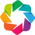

In [47]:
import pandas as pd
import holoviews as hv
from holoviews import opts
from bokeh.models import HoverTool

hv.extension("bokeh")

# chord_df should have: origin, destination, flow
chord_df = chord_df.copy()

# Optional: make flow readable in tooltip
# if ran once flow if run again Flow
if "Flow" not in chord_df.columns and "flow" in chord_df.columns:
    chord_df = chord_df.rename(columns={"flow": "Flow"})
chord_df["flow_label"] = chord_df["Flow"].round(0).astype(int).map("{:,}".format)

# Rename for cleaner tooltip display
chord_df = chord_df.rename(columns={
    "origin_name": "Origin",
    "destination_name": "Destination",
    "Flow": "Flow"
})

nodes = pd.DataFrame({
    "index": list(top15_units),
    "name": list(top15_units)
})


def clean_chord_tooltip(plot, element):
    """
    Improve hover tooltip for chord edges.
    Shows origin, destination, and flow value.
    """
    for tool in plot.state.tools:
        if isinstance(tool, HoverTool):
            tool.tooltips = [
                ("Origin", "@Origin"),
                ("Destination", "@Destination"),
                ("Flow", "@flow_label"),
            ]

chord = hv.Chord(
    (
        chord_df,
        hv.Dataset(nodes, "index")
    )
)

chord = chord.opts(
    opts.Chord(
        labels="name",              # only show unit names around circle
        node_color="index",
        edge_color="Origin",
        cmap="Category20",
        edge_cmap="Category20",
        width=850,
        height=850,
        title=f"Top 15 OD migration flows: {duration}-day definition",
        tools=["hover"],
        inspection_policy="edges",
        hooks=[clean_chord_tooltip],

        # Bigger location labels
        fontsize={
            'title': '18pt',
            'labels': '18pt'
        }
    )
)

hv.save(chord, f"top15_{duration}_chord_diagram.html")